# MelCNN MGR Manifest, Log-Mel, TFRecord, and Training EDA

This notebook audits the current MelCNN MGR pipeline after the latest end-to-end run:

1. `1_build_all_datasets_and_samples_v1_1.py` stage 1 for FMA
2. `1_build_all_datasets_and_samples_v1_1.py` stage 1 for additional datasets
3. `1_build_all_datasets_and_samples_v1_1.py` stage 2 final split selection
4. `2_build_log_mel_dataset.py`
5. `3_convert_npy_2_tfrecord.py`
6. `logmel_cnn_v2_4_1_cuda_tf.py`

The audit is centered on the live artifacts now present in the repo and current training cache roots:

1. source-split processed manifests in `MelCNN-MGR/data/processed`
2. the final selected segment manifest in `MelCNN-MGR/data/processed/manifest_final_samples.parquet`
3. external log-mel outputs under the latest generated log-mel root
4. external TFRecord outputs under the latest generated TFRecord root
5. the latest training run report and saved feature configuration

The goal is to verify that the current multi-source pipeline remains coherent from discovery, to segment generation, to final split selection, to log-mel materialization, to TFRecord conversion, and finally to the trained model metadata.

## Notebook Map

The notebook follows the current pipeline in execution order and then audits the downstream handoff into training artifacts:

1. resolve repo paths and detect the latest generated downstream roots
2. inspect processed manifest artifacts and schema contracts
3. audit file-level discovery and skip logic across FMA and additional sources
4. audit segment expansion and final split selection
5. check leakage safety and additional-source contribution
6. keep the small-split supplementation audit as an optional branch when those artifacts exist
7. inspect downstream log-mel manifests
8. inspect downstream TFRecord manifests and shard indexes
9. inspect the latest training run report and saved feature configuration
10. summarize readiness, divergence, and remaining gaps

In [1]:
from __future__ import annotations

import hashlib
import json
import random
import re
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Markdown, display

pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
pd.set_option('display.max_colwidth', 160)

NOTEBOOK_NAME = 'MelCNN_MGR_Manifest_LogMel_EDA'


def resolve_project_paths(start: Path) -> tuple[Path, Path]:
    candidates = [start.resolve(), *start.resolve().parents]
    for candidate in candidates:
        if (candidate / 'MelCNN-MGR' / 'settings.json').exists():
            return candidate, candidate / 'MelCNN-MGR'
        if candidate.name == 'MelCNN-MGR' and (candidate / 'settings.json').exists():
            return candidate.parent, candidate
    raise FileNotFoundError('Could not locate workspace root containing MelCNN-MGR/settings.json')


def safe_read_json(path: Path | None) -> dict[str, object] | None:
    if path is None or not path.exists():
        return None
    return json.loads(path.read_text())


def first_existing(paths: list[Path | None]) -> Path | None:
    for path in paths:
        if path is not None and path.exists():
            return path
    return None


WORKSPACE_ROOT, MELCNN_DIR = resolve_project_paths(Path.cwd())
PROCESSED_DIR = MELCNN_DIR / 'data' / 'processed'
SETTINGS_PATH = MELCNN_DIR / 'settings.json'
TRACKS_CSV = WORKSPACE_ROOT / 'FMA' / 'fma_metadata' / 'tracks.csv'
EXTRA_SAMPLES_PATH = PROCESSED_DIR / 'extra_samples_for_small_dataset.json'

FMA_DATASETS_PATH = PROCESSED_DIR / 'manifest_fma_datasets.parquet'
FMA_ALL_SAMPLES_PATH = PROCESSED_DIR / 'manifest_fma_all_samples.parquet'
ADDITIONAL_DATASETS_PATH = PROCESSED_DIR / 'manifest_additional_datasets.parquet'
ADDITIONAL_ALL_SAMPLES_PATH = PROCESSED_DIR / 'manifest_additional_all_samples.parquet'
FINAL_SAMPLES_PATH = PROCESSED_DIR / 'manifest_final_samples.parquet'
FINAL_CONFIG_PATH = PROCESSED_DIR / 'manifest_final_samples.config.json'
FINAL_REPORT_PATH = PROCESSED_DIR / 'manifest_final_samples.report.txt'

SOURCE_DATASET_PATHS = {
    'fma': FMA_DATASETS_PATH,
    'additional': ADDITIONAL_DATASETS_PATH,
}
SOURCE_SAMPLE_PATHS = {
    'fma': FMA_ALL_SAMPLES_PATH,
    'additional': ADDITIONAL_ALL_SAMPLES_PATH,
}

SUPPLEMENTED_TARGET_SUBSET = 'small'
SUPPLEMENTED_SPLIT_ORDER = ['training', 'validation', 'test']
SUPPLEMENTED_SPLIT_FILES = {
    'training': f'train_{SUPPLEMENTED_TARGET_SUBSET}.parquet',
    'validation': f'val_{SUPPLEMENTED_TARGET_SUBSET}.parquet',
    'test': f'test_{SUPPLEMENTED_TARGET_SUBSET}.parquet',
}
SUPPLEMENTATION_BASE_RANDOM_SEED = 20260309

run_report_candidates = sorted((MELCNN_DIR / 'demo-models').glob('**/run_report_*.json'))
run_report_candidates += sorted((MELCNN_DIR / 'models').glob('**/run_report_*.json'))
LATEST_RUN_REPORT_PATH = max(run_report_candidates, key=lambda path: path.stat().st_mtime) if run_report_candidates else None
LATEST_RUN_REPORT = safe_read_json(LATEST_RUN_REPORT_PATH)
LATEST_RUN_DIR = None if LATEST_RUN_REPORT_PATH is None else LATEST_RUN_REPORT_PATH.parent

logmel_dir_candidates = [
    None if not isinstance(LATEST_RUN_REPORT, dict) else Path(str(LATEST_RUN_REPORT.get('source_logmel_root', '') or '')),
    Path('/home/hsnguyen/model-training-data-cache/logmel_dataset_10s'),
    MELCNN_DIR / 'cache' / 'logmel_dataset_10s',
]
tfrecord_dir_candidates = [
    None if not isinstance(LATEST_RUN_REPORT, dict) else Path(str(LATEST_RUN_REPORT.get('tfrecord_dataset_dir', '') or '')),
    Path('/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord'),
]

LOGMEL_DATASET_DIR = first_existing(logmel_dir_candidates)
TFRECORD_DATASET_DIR = first_existing(tfrecord_dir_candidates)

LOGMEL_CONFIG_PATH = None if LOGMEL_DATASET_DIR is None else LOGMEL_DATASET_DIR / 'logmel_config.json'
LOGMEL_ALL_PATH = None if LOGMEL_DATASET_DIR is None else LOGMEL_DATASET_DIR / 'logmel_manifest_all.parquet'
LOGMEL_TRAIN_PATH = None if LOGMEL_DATASET_DIR is None else LOGMEL_DATASET_DIR / 'logmel_manifest_train.parquet'
LOGMEL_VAL_PATH = None if LOGMEL_DATASET_DIR is None else LOGMEL_DATASET_DIR / 'logmel_manifest_val.parquet'
LOGMEL_TEST_PATH = None if LOGMEL_DATASET_DIR is None else LOGMEL_DATASET_DIR / 'logmel_manifest_test.parquet'

TFRECORD_CONFIG_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_config.json'
TFRECORD_ALL_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_manifest_all.parquet'
TFRECORD_TRAIN_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_manifest_train.parquet'
TFRECORD_VAL_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_manifest_val.parquet'
TFRECORD_TEST_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_manifest_test.parquet'
TFRECORD_SHARDS_ALL_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_shards_all.parquet'
TFRECORD_SHARDS_TRAIN_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_shards_train.parquet'
TFRECORD_SHARDS_VAL_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_shards_val.parquet'
TFRECORD_SHARDS_TEST_PATH = None if TFRECORD_DATASET_DIR is None else TFRECORD_DATASET_DIR / 'tfrecord_shards_test.parquet'

print(f'Loaded helpers for {NOTEBOOK_NAME}')
print(f'Workspace root       : {WORKSPACE_ROOT}')
print(f'Processed dir        : {PROCESSED_DIR}')
print(f'Latest run report    : {LATEST_RUN_REPORT_PATH}')
print(f'Latest run dir       : {LATEST_RUN_DIR}')
print(f'Log-mel dataset dir  : {LOGMEL_DATASET_DIR}')
print(f'TFRecord dataset dir : {TFRECORD_DATASET_DIR}')

Loaded helpers for MelCNN_MGR_Manifest_LogMel_EDA
Workspace root       : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1
Processed dir        : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed
Latest run report    : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/demo-models/logmel-cnn-v2_4-cuda-tf-20260320-033255/run_report_logmel_cnn_v2_4_1_cuda_tf.json
Latest run dir       : /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/demo-models/logmel-cnn-v2_4-cuda-tf-20260320-033255
Log-mel dataset dir  : /home/hsnguyen/model-training-data-cache/logmel_dataset_10s
TFRecord dataset dir : /home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord


In [2]:
def display_frame_overview(name: str, frame: pd.DataFrame, head_rows: int = 5) -> None:
    display(Markdown(f'### {name}'))
    print(f'shape = {frame.shape}')
    display(frame.head(head_rows))
    dtype_frame = pd.DataFrame({
        'column': frame.columns,
        'dtype': [str(dtype) for dtype in frame.dtypes],
        'null_count': frame.isna().sum().values,
        'null_pct': (frame.isna().mean() * 100).round(2).values,
    })
    display(dtype_frame)


def display_json_table(title: str, payload: dict[str, object] | None) -> None:
    display(Markdown(f'### {title}'))
    if not payload:
        print('Not available.')
        return
    rows = []
    for key, value in payload.items():
        if isinstance(value, (dict, list)):
            rows.append({'key': key, 'value': json.dumps(value, ensure_ascii=False)[:300]})
        else:
            rows.append({'key': key, 'value': value})
    display(pd.DataFrame(rows))


def imbalance_table(series: pd.Series, name: str | None = None) -> pd.DataFrame:
    counts = series.value_counts(dropna=False)
    label = name or series.name or 'category'
    if counts.empty:
        return pd.DataFrame(columns=[label, 'count', 'proportion_pct', 'imbalance_ratio_vs_max'])
    table = counts.rename_axis(label).reset_index(name='count')
    table['proportion_pct'] = (table['count'] / table['count'].sum() * 100).round(2)
    table['imbalance_ratio_vs_max'] = (table['count'].max() / table['count']).round(3)
    return table


def plot_bar(series: pd.Series, title: str, xlabel: str = '', ylabel: str = 'count', rotation: int = 45, figsize: tuple[int, int] = (10, 5), color: str = '#4C78A8') -> None:
    data = series.sort_values(ascending=False)
    _, ax = plt.subplots(figsize=figsize)
    data.plot(kind='bar', ax=ax, color=color)
    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.tick_params(axis='x', rotation=rotation)
    plt.tight_layout()
    plt.show()


def plot_hist(series: pd.Series, title: str, bins: int = 40, figsize: tuple[int, int] = (10, 5), color: str = '#72B7B2') -> None:
    clean = pd.to_numeric(series, errors='coerce').dropna()
    _, ax = plt.subplots(figsize=figsize)
    ax.hist(clean, bins=bins, color=color, edgecolor='white')
    ax.set_title(title)
    ax.set_xlabel(series.name or 'value')
    ax.set_ylabel('count')
    plt.tight_layout()
    plt.show()


def plot_heatmap(table: pd.DataFrame, title: str, figsize: tuple[int, int] = (10, 6), fmt: str = '.0f') -> None:
    numeric_table = table.apply(pd.to_numeric, errors='coerce')
    if numeric_table.empty:
        print(f'No data available for {title}')
        return
    _, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(numeric_table.values, aspect='auto', cmap='YlGnBu')
    ax.set_xticks(np.arange(numeric_table.shape[1]))
    ax.set_yticks(np.arange(numeric_table.shape[0]))
    ax.set_xticklabels(numeric_table.columns)
    ax.set_yticklabels(numeric_table.index)
    for i in range(numeric_table.shape[0]):
        for j in range(numeric_table.shape[1]):
            value = numeric_table.values[i, j]
            label = '' if pd.isna(value) else format(value, fmt)
            ax.text(j, i, label, ha='center', va='center', color='black', fontsize=8)
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    plt.tight_layout()
    plt.show()


def artifact_id_from_sample_id(sample_id: str) -> str:
    return re.sub(r':seg\d+$', '', str(sample_id))


def safe_read_parquet(path: Path | None) -> pd.DataFrame | None:
    if path is None or not path.exists():
        return None
    return pd.read_parquet(path)


def combine_frames(frames: dict[str, pd.DataFrame | None]) -> pd.DataFrame:
    available = [frame.assign(_source_manifest=name) for name, frame in frames.items() if frame is not None]
    if not available:
        return pd.DataFrame()
    return pd.concat(available, axis=0, ignore_index=True)


def build_schema_check(artifact: str, frame: pd.DataFrame | None, expected_columns: list[str]) -> dict[str, object]:
    if frame is None:
        return {
            'artifact': artifact,
            'exists': False,
            'expected_columns_match': False,
            'missing_columns': expected_columns,
            'extra_columns': [],
        }
    return {
        'artifact': artifact,
        'exists': True,
        'expected_columns_match': list(frame.columns) == expected_columns,
        'missing_columns': sorted(set(expected_columns) - set(frame.columns)),
        'extra_columns': sorted(set(frame.columns) - set(expected_columns)),
    }

In [3]:
settings_payload = safe_read_json(SETTINGS_PATH)
final_manifest_config = safe_read_json(FINAL_CONFIG_PATH)
logmel_config = safe_read_json(LOGMEL_CONFIG_PATH)
tfrecord_config = safe_read_json(TFRECORD_CONFIG_PATH)
run_report = LATEST_RUN_REPORT
manifest_report_preview = FINAL_REPORT_PATH.read_text().splitlines()[:80] if FINAL_REPORT_PATH.exists() else []

source_dataset_frames = {name: safe_read_parquet(path) for name, path in SOURCE_DATASET_PATHS.items()}
source_sample_frames = {name: safe_read_parquet(path) for name, path in SOURCE_SAMPLE_PATHS.items()}

fma_datasets_df = source_dataset_frames.get('fma')
additional_datasets_df = source_dataset_frames.get('additional')
fma_all_samples_df = source_sample_frames.get('fma')
additional_all_samples_df = source_sample_frames.get('additional')

all_datasets_df = combine_frames(source_dataset_frames)
all_samples_df = combine_frames(source_sample_frames)
final_samples_df = pd.read_parquet(FINAL_SAMPLES_PATH)

logmel_all_df = safe_read_parquet(LOGMEL_ALL_PATH)
logmel_train_df = safe_read_parquet(LOGMEL_TRAIN_PATH)
logmel_val_df = safe_read_parquet(LOGMEL_VAL_PATH)
logmel_test_df = safe_read_parquet(LOGMEL_TEST_PATH)

tfrecord_all_df = safe_read_parquet(TFRECORD_ALL_PATH)
tfrecord_train_df = safe_read_parquet(TFRECORD_TRAIN_PATH)
tfrecord_val_df = safe_read_parquet(TFRECORD_VAL_PATH)
tfrecord_test_df = safe_read_parquet(TFRECORD_TEST_PATH)
tfrecord_shards_all_df = safe_read_parquet(TFRECORD_SHARDS_ALL_PATH)
tfrecord_shards_train_df = safe_read_parquet(TFRECORD_SHARDS_TRAIN_PATH)
tfrecord_shards_val_df = safe_read_parquet(TFRECORD_SHARDS_VAL_PATH)
tfrecord_shards_test_df = safe_read_parquet(TFRECORD_SHARDS_TEST_PATH)

sampling_settings = (settings_payload or {}).get('data_sampling_settings', {})
model_inference_settings = (settings_payload or {}).get('model_inference_settings', {})

artifact_rows = [
    {'artifact': 'manifest_fma_datasets', 'path': str(FMA_DATASETS_PATH), 'exists': FMA_DATASETS_PATH.exists(), 'rows': 0 if fma_datasets_df is None else len(fma_datasets_df), 'columns': 0 if fma_datasets_df is None else fma_datasets_df.shape[1]},
    {'artifact': 'manifest_additional_datasets', 'path': str(ADDITIONAL_DATASETS_PATH), 'exists': ADDITIONAL_DATASETS_PATH.exists(), 'rows': 0 if additional_datasets_df is None else len(additional_datasets_df), 'columns': 0 if additional_datasets_df is None else additional_datasets_df.shape[1]},
    {'artifact': 'manifest_fma_all_samples', 'path': str(FMA_ALL_SAMPLES_PATH), 'exists': FMA_ALL_SAMPLES_PATH.exists(), 'rows': 0 if fma_all_samples_df is None else len(fma_all_samples_df), 'columns': 0 if fma_all_samples_df is None else fma_all_samples_df.shape[1]},
    {'artifact': 'manifest_additional_all_samples', 'path': str(ADDITIONAL_ALL_SAMPLES_PATH), 'exists': ADDITIONAL_ALL_SAMPLES_PATH.exists(), 'rows': 0 if additional_all_samples_df is None else len(additional_all_samples_df), 'columns': 0 if additional_all_samples_df is None else additional_all_samples_df.shape[1]},
    {'artifact': 'manifest_final_samples', 'path': str(FINAL_SAMPLES_PATH), 'exists': FINAL_SAMPLES_PATH.exists(), 'rows': len(final_samples_df), 'columns': final_samples_df.shape[1]},
    {'artifact': 'logmel_manifest_all', 'path': None if LOGMEL_ALL_PATH is None else str(LOGMEL_ALL_PATH), 'exists': LOGMEL_ALL_PATH is not None and LOGMEL_ALL_PATH.exists(), 'rows': 0 if logmel_all_df is None else len(logmel_all_df), 'columns': 0 if logmel_all_df is None else logmel_all_df.shape[1]},
    {'artifact': 'tfrecord_manifest_all', 'path': None if TFRECORD_ALL_PATH is None else str(TFRECORD_ALL_PATH), 'exists': TFRECORD_ALL_PATH is not None and TFRECORD_ALL_PATH.exists(), 'rows': 0 if tfrecord_all_df is None else len(tfrecord_all_df), 'columns': 0 if tfrecord_all_df is None else tfrecord_all_df.shape[1]},
    {'artifact': 'tfrecord_shards_all', 'path': None if TFRECORD_SHARDS_ALL_PATH is None else str(TFRECORD_SHARDS_ALL_PATH), 'exists': TFRECORD_SHARDS_ALL_PATH is not None and TFRECORD_SHARDS_ALL_PATH.exists(), 'rows': 0 if tfrecord_shards_all_df is None else len(tfrecord_shards_all_df), 'columns': 0 if tfrecord_shards_all_df is None else tfrecord_shards_all_df.shape[1]},
    {'artifact': 'latest_run_report', 'path': None if LATEST_RUN_REPORT_PATH is None else str(LATEST_RUN_REPORT_PATH), 'exists': LATEST_RUN_REPORT_PATH is not None and LATEST_RUN_REPORT_PATH.exists(), 'rows': None, 'columns': None},
]
artifact_inventory = pd.DataFrame(artifact_rows)

config_rows = [
    {'key': 'workspace_root', 'value': str(WORKSPACE_ROOT)},
    {'key': 'melcnn_dir', 'value': str(MELCNN_DIR)},
    {'key': 'processed_dir', 'value': str(PROCESSED_DIR)},
    {'key': 'latest_run_report', 'value': None if LATEST_RUN_REPORT_PATH is None else str(LATEST_RUN_REPORT_PATH)},
    {'key': 'latest_run_id', 'value': None if not isinstance(run_report, dict) else run_report.get('run_id')},
    {'key': 'configured_demo_model_name', 'value': model_inference_settings.get('model_name')},
    {'key': 'logmel_dataset_dir', 'value': None if LOGMEL_DATASET_DIR is None else str(LOGMEL_DATASET_DIR)},
    {'key': 'tfrecord_dataset_dir', 'value': None if TFRECORD_DATASET_DIR is None else str(TFRECORD_DATASET_DIR)},
    {'key': 'target_genres', 'value': ', '.join(sampling_settings.get('target_genres', []))},
    {'key': 'sample_length_sec', 'value': sampling_settings.get('sample_length_sec')},
    {'key': 'number_of_samples_expected_each_genre', 'value': sampling_settings.get('number_of_samples_expected_each_genre')},
    {'key': 'additional_samples_contribution_ratio_expected_each_genre', 'value': sampling_settings.get('additional_samples_contribution_ratio_expected_each_genre')},
    {'key': 'train_n_val_test_split_ratio_each_genre', 'value': sampling_settings.get('train_n_val_test_split_ratio_each_genre')},
    {'key': 'final_manifest_generated_at', 'value': None if final_manifest_config is None else final_manifest_config.get('generated_at')},
    {'key': 'logmel_config_generated_at', 'value': None if logmel_config is None else logmel_config.get('generated_at')},
    {'key': 'tfrecord_config_generated_at', 'value': None if tfrecord_config is None else tfrecord_config.get('generated_at')},
    {'key': 'training_run_generated_at', 'value': None if not isinstance(run_report, dict) else run_report.get('generated_at')},
]

display(Markdown('## Configuration and Artifact Presence'))
display(pd.DataFrame(config_rows))
display(artifact_inventory)

if manifest_report_preview:
    display(Markdown('## Final Manifest Report Preview'))
    print('\n'.join(manifest_report_preview))

## Configuration and Artifact Presence

,key,value
0,workspace_root,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1
1,melcnn_dir,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR
2,processed_dir,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed
3,latest_run_report,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/demo-models/logmel-cnn-v2_4-cuda-tf-20260320-033255/run_report_logmel_cnn_v2_4_1_cuda_tf.json
4,latest_run_id,logmel-cnn-v2_4-cuda-tf-20260320-033255
5,configured_demo_model_name,logmel-cnn-v2_4-cuda-tf-20260319-155604_10s
6,logmel_dataset_dir,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s
7,tfrecord_dataset_dir,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord
8,target_genres,"Hip-Hop, Pop, Rock, Metal, Classical, Jazz, Country, Blues, Bolero, Speech"
9,sample_length_sec,10


,artifact,path,exists,rows,columns
0,manifest_fma_datasets,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_fma_datasets.parquet,True,8745.0,15.0
1,manifest_additional_datasets,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_additional_datasets.parquet,True,11158.0,15.0
2,manifest_fma_all_samples,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_fma_all_samples.parquet,True,26204.0,14.0
3,manifest_additional_all_samples,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_additional_all_samples.parquet,True,33140.0,14.0
4,manifest_final_samples,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_final_samples.parquet,True,31826.0,14.0
5,logmel_manifest_all,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s/logmel_manifest_all.parquet,True,31826.0,25.0
6,tfrecord_manifest_all,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord/tfrecord_manifest_all.parquet,True,31018.0,32.0
7,tfrecord_shards_all,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord/tfrecord_shards_all.parquet,True,32.0,5.0
8,latest_run_report,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/demo-models/logmel-cnn-v2_4-cuda-tf-20260320-033255/run_report_logmel_cnn_v2_4_1_cuda_tf.json,True,NaN,NaN


## Final Manifest Report Preview

build_all_datasets_and_samples report
Generated : 2026-03-20 01:13:25 UTC

── Configuration ───────────────────────────────────────
  mode: stage2
  stage1a_sources: both
  stage1b_sources: both
  target_genres: ['Hip-Hop', 'Pop', 'Rock', 'Metal', 'Classical', 'Jazz', 'Country', 'Blues', 'Bolero', 'Speech']
  sample_length_sec: 10.0
  min_duration_delta: 0.001
  number_of_samples_expected_each_genre: 3200
  additional_samples_contribution_ratio_expected_each_genre: 0.7
  train_n_val_test_split_ratio_each_genre: 0.7
  split_seed: 1337
  fma_subset: medium
  min_duration_s: 9.999
  min_duration_source: sample_length_sec_minus_delta
  force_rescan: False
  medium_manifest: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/metadata_manifest_medium.parquet
  fma_metadata_root: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_metadata
  fma_audio_root: /mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_medium
  additional_root: /mnt/d/

## Schema Inspection

This section checks the live artifact schemas against the current pipeline contract.

The main expectations are now:

- `manifest_fma_datasets.parquet` and `manifest_additional_datasets.parquet` are the file-level discovery and skip-audit tables
- `manifest_fma_all_samples.parquet` and `manifest_additional_all_samples.parquet` are the full segment-expansion tables emitted by stage 1
- `manifest_final_samples.parquet` is the selected segment-level training manifest emitted by stage 2
- optional downstream log-mel manifests should derive from `manifest_final_samples.parquet`
- optional downstream TFRecord manifests should derive from the log-mel manifests

In [4]:
if fma_datasets_df is not None:
    display_frame_overview('manifest_fma_datasets', fma_datasets_df)
if additional_datasets_df is not None:
    display_frame_overview('manifest_additional_datasets', additional_datasets_df)
if fma_all_samples_df is not None:
    display_frame_overview('manifest_fma_all_samples', fma_all_samples_df)
if additional_all_samples_df is not None:
    display_frame_overview('manifest_additional_all_samples', additional_all_samples_df)
display_frame_overview('manifest_final_samples', final_samples_df)

expected_dataset_columns = [
    'source', 'artifact_id', 'source_track_id', 'track_id', 'genre_top', 'filepath',
    'audio_exists', 'filesize_bytes', 'actual_duration_s', 'duration_s', 'reason_code',
    'sampling_eligible', 'sampling_num_segments', 'sampling_exclusion_reason', 'manifest_origin',
]
expected_source_sample_columns = [
    'sample_id', 'artifact_id', 'source', 'genre_top', 'filepath', 'track_id', 'sample_length_sec',
    'segment_index', 'segment_start_sec', 'segment_end_sec', 'total_segments_from_audio',
    'duration_s', 'actual_duration_s', 'reason_code',
]
expected_final_sample_columns = [
    'sample_id', 'source', 'genre_top', 'filepath', 'track_id', 'sample_length_sec',
    'segment_index', 'segment_start_sec', 'segment_end_sec', 'total_segments_from_audio',
    'duration_s', 'actual_duration_s', 'reason_code', 'final_split',
]

schema_checks = pd.DataFrame([
    build_schema_check('manifest_fma_datasets', fma_datasets_df, expected_dataset_columns),
    build_schema_check('manifest_additional_datasets', additional_datasets_df, expected_dataset_columns),
    build_schema_check('manifest_fma_all_samples', fma_all_samples_df, expected_source_sample_columns),
    build_schema_check('manifest_additional_all_samples', additional_all_samples_df, expected_source_sample_columns),
    build_schema_check('manifest_final_samples', final_samples_df, expected_final_sample_columns),
])

display(Markdown('## Schema Contract Checks'))
display(schema_checks)

### manifest_fma_datasets

shape = (8745, 15)


,source,artifact_id,source_track_id,track_id,genre_top,filepath,audio_exists,filesize_bytes,actual_duration_s,duration_s,reason_code,sampling_eligible,sampling_num_segments,sampling_exclusion_reason,manifest_origin
0,fma-medium,997e088b50afc0ae2c625a7c8ce8c10d,3,3,Hip-Hop,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_medium/000/000003.mp3,True,961632,30.014694,30.0,OK,True,3,None,from_scratch:/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_metadata
1,fma-medium,18a5dd9f5dba7c971b69229c91e024dc,134,134,Hip-Hop,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_medium/000/000134.mp3,True,961887,30.014694,30.0,OK,True,3,None,from_scratch:/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_metadata
2,fma-medium,7cd452e46a8c116eaa93715b49c104cc,136,136,Rock,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_medium/000/000136.mp3,True,960877,29.988571,30.0,OK,True,3,None,from_scratch:/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_metadata
3,fma-medium,fefdfb8298926784fb8a65362facd7f2,181,181,Rock,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_medium/000/000181.mp3,True,961943,30.014694,30.0,OK,True,3,None,from_scratch:/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_metadata
4,fma-medium,c258760e654f0ce00735f8cc5b919a95,237,237,Jazz,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_medium/000/000237.mp3,True,960721,29.988571,30.0,OK,True,3,None,from_scratch:/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_metadata


,column,dtype,null_count,null_pct
0,source,object,0,0.00
1,artifact_id,object,0,0.00
2,source_track_id,object,0,0.00
3,track_id,Int64,0,0.00
4,genre_top,object,0,0.00
5,filepath,object,0,0.00
6,audio_exists,bool,0,0.00
7,filesize_bytes,Int64,0,0.00
8,actual_duration_s,float64,8,0.09
9,duration_s,float64,8,0.09


### manifest_additional_datasets

...

shape = (31826, 14)


,sample_id,source,genre_top,filepath,track_id,sample_length_sec,segment_index,segment_start_sec,segment_end_sec,total_segments_from_audio,duration_s,actual_duration_s,reason_code,final_split
0,006e4f445a7d6a4aefedb5c9093e2f39:seg0000,my-collection,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/my-collection/blues/Bourbon Blues__seg06_start420.13s.wav,<NA>,10.0,0,0.0,10.0,3,31.0,31.0,OK,test
1,006e4f445a7d6a4aefedb5c9093e2f39:seg0001,my-collection,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/my-collection/blues/Bourbon Blues__seg06_start420.13s.wav,<NA>,10.0,1,10.0,20.0,3,31.0,31.0,OK,test
2,006e4f445a7d6a4aefedb5c9093e2f39:seg0002,my-collection,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/my-collection/blues/Bourbon Blues__seg06_start420.13s.wav,<NA>,10.0,2,20.0,30.0,3,31.0,31.0,OK,test
3,01651ad200808ecf077d90061b54794b:seg0000,mtg-jamendo,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/mtg-jamendo/blues/1219560__seg02_start057.26s.wav,<NA>,10.0,0,0.0,10.0,3,31.0,31.0,OK,test
4,01651ad200808ecf077d90061b54794b:seg0001,mtg-jamendo,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/mtg-jamendo/blues/1219560__seg02_start057.26s.wav,<NA>,10.0,1,10.0,20.0,3,31.0,31.0,OK,test


,column,dtype,null_count,null_pct
0,sample_id,object,0,0.00
1,source,object,0,0.00
2,genre_top,object,0,0.00
3,filepath,object,0,0.00
4,track_id,Int64,26672,83.81
5,sample_length_sec,float64,0,0.00
6,segment_index,int64,0,0.00
7,segment_start_sec,float64,0,0.00
8,segment_end_sec,float64,0,0.00
9,total_segments_from_audio,Int64,0,0.00


## Schema Contract Checks

,artifact,exists,expected_columns_match,missing_columns,extra_columns
0,manifest_fma_datasets,True,True,[],[]
1,manifest_additional_datasets,True,True,[],[]
2,manifest_fma_all_samples,True,True,[],[]
3,manifest_additional_all_samples,True,True,[],[]
4,manifest_final_samples,True,True,[],[]


## File-Level Discovery and Skip Logic

This section studies the current file-level manifests emitted by stage 1.

Focus areas:

- source composition across FMA and additional datasets
- genre composition
- reason-code outcomes
- sampling eligibility
- measured and normalized durations

,metric,value
0,total_discovered_audio_candidates,19903
1,audio_exists_true,19903
2,reason_code_OK,19782
3,sampling_eligible_true,19782
4,unique_sources,4
5,unique_genres,10


### Counts by Manifest Source

,source_manifest,count
0,additional,11158
1,fma,8745


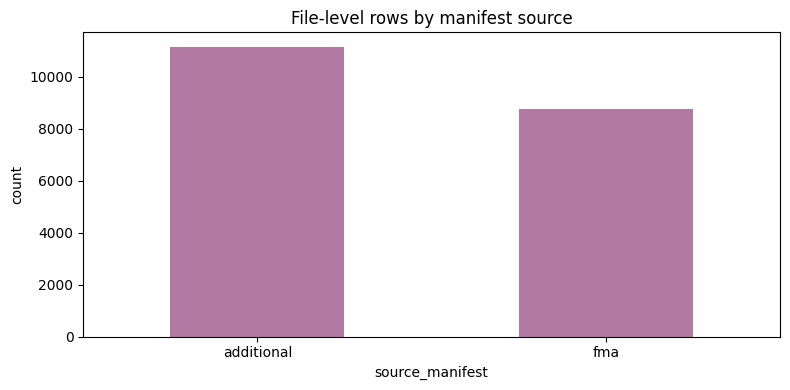

### Counts by Source

,source,count
0,fma-medium,8745
1,my-collection,7853
2,mtg-jamendo,2605
3,gtzan,700


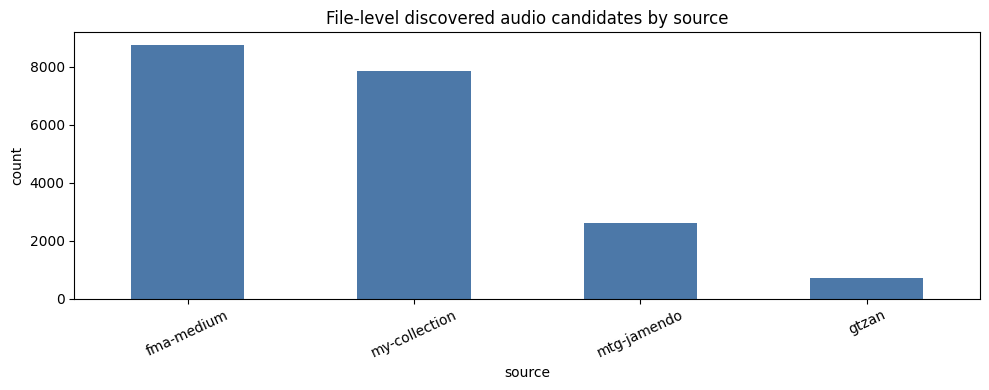

### Counts by Genre

,genre_top,count,proportion_pct,imbalance_ratio_vs_max
0,Rock,7013,35.24,1.000
1,Hip-Hop,1984,9.97,3.535
2,Classical,1638,8.23,4.281
3,Jazz,1524,7.66,4.602
4,Pop,1485,7.46,4.723
5,Bolero,1469,7.38,4.774
6,Blues,1447,7.27,4.847
7,Speech,1218,6.12,5.758
8,Country,1120,5.63,6.262
9,Metal,1005,5.05,6.978


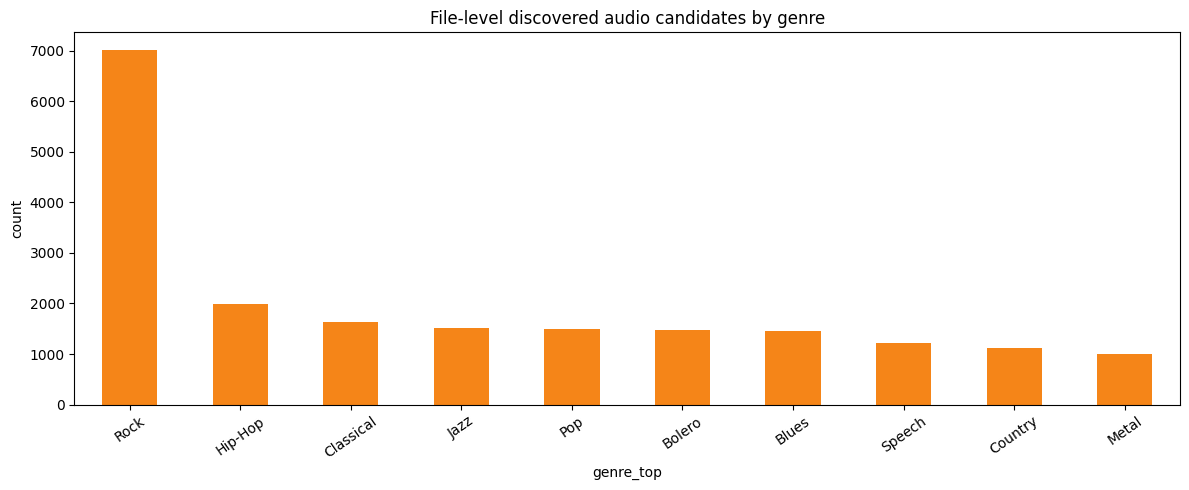

### Reason Code Breakdown

,reason_code,count
0,OK,19782
1,TOO_SHORT,104
2,AUDIO_READ_FAILED,17


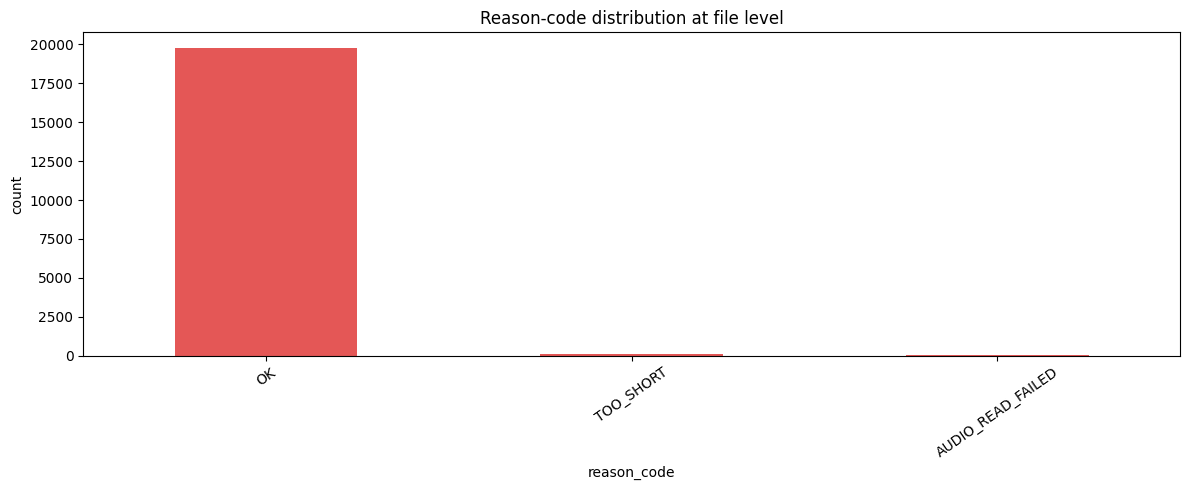

### Source by Reason Code

reason_code,AUDIO_READ_FAILED,OK,TOO_SHORT
source,,,
fma-medium,8,8735,2
gtzan,1,699,0
mtg-jamendo,0,2605,0
my-collection,8,7743,102


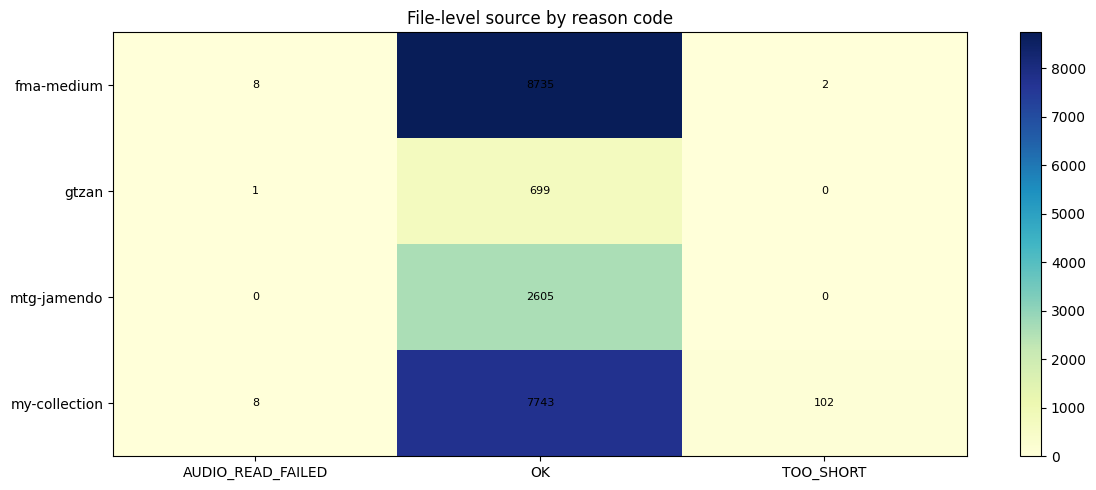

### Sampling Eligibility

,sampling_eligible,count
0,True,19782
1,False,121


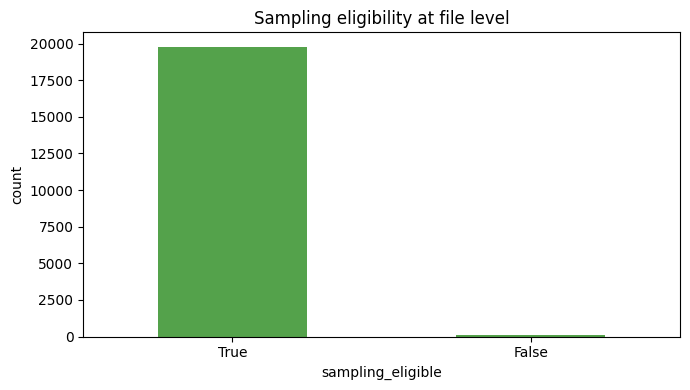

### Duration Summary

,count,mean,std,min,25%,50%,75%,max,missing_pct
actual_duration_s,19886.0,30.364490,2.249925,0.0,30.0,31.0,31.0,31.0,0.09
duration_s,19886.0,30.365534,2.249375,0.0,30.0,31.0,31.0,31.0,0.09


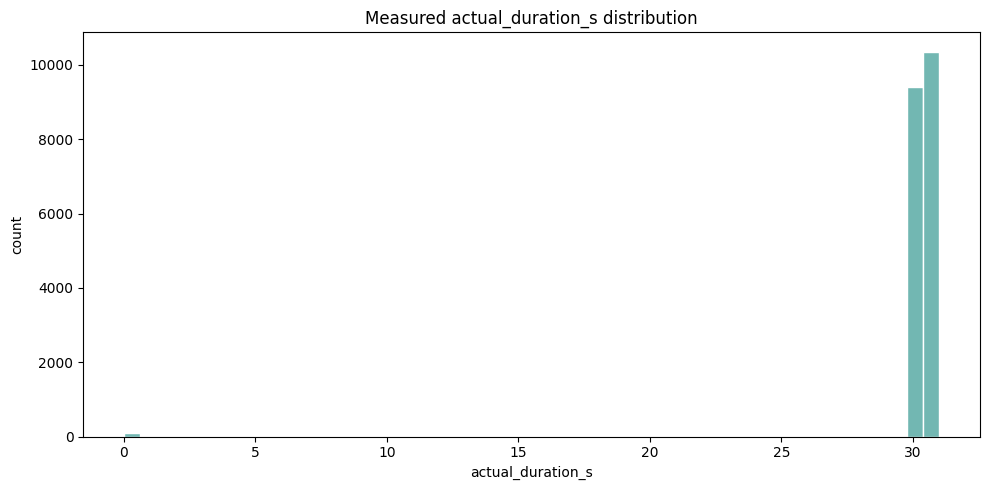

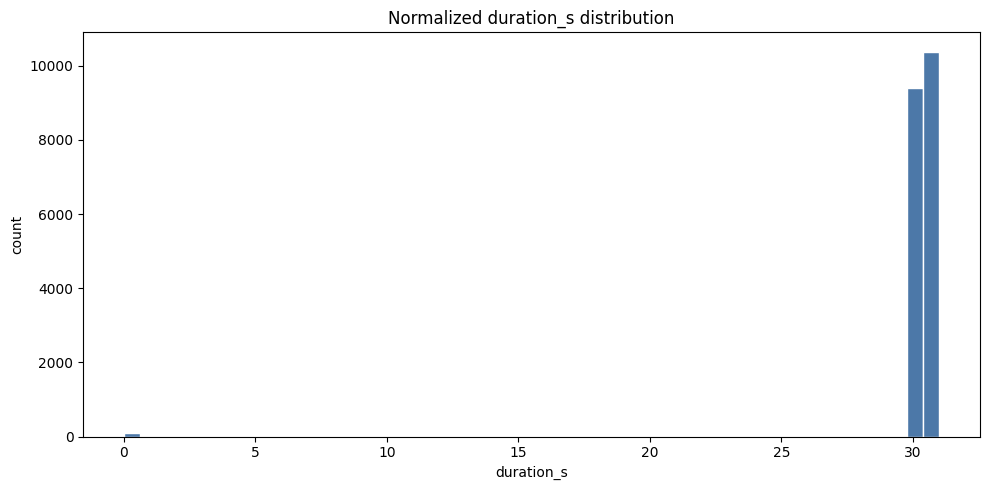

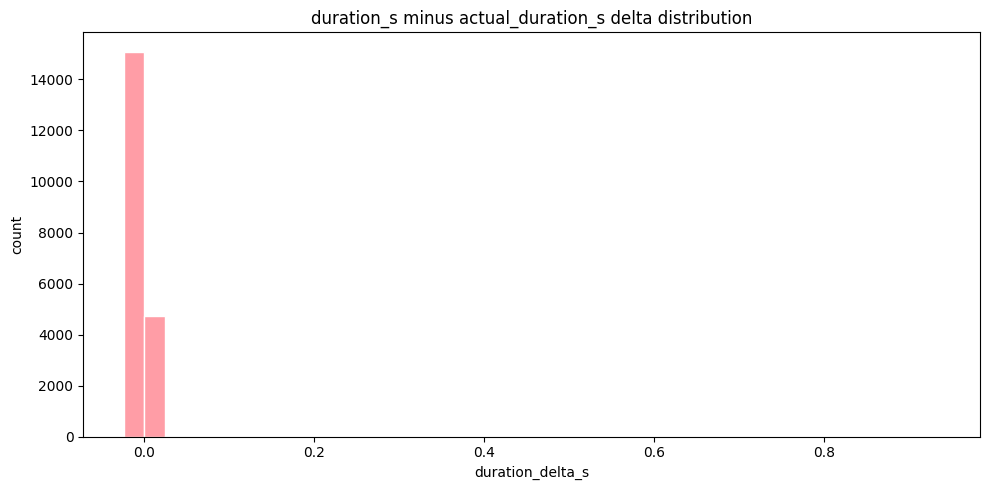

In [5]:
file_level_summary = pd.DataFrame([
    {'metric': 'total_discovered_audio_candidates', 'value': len(all_datasets_df)},
    {'metric': 'audio_exists_true', 'value': int(all_datasets_df['audio_exists'].fillna(False).sum())},
    {'metric': 'reason_code_OK', 'value': int((all_datasets_df['reason_code'] == 'OK').sum())},
    {'metric': 'sampling_eligible_true', 'value': int(all_datasets_df['sampling_eligible'].fillna(False).sum())},
    {'metric': 'unique_sources', 'value': all_datasets_df['source'].nunique(dropna=True)},
    {'metric': 'unique_genres', 'value': all_datasets_df['genre_top'].nunique(dropna=True)},
])
display(file_level_summary)

source_manifest_counts = all_datasets_df['_source_manifest'].value_counts()
source_counts = all_datasets_df['source'].value_counts()
genre_counts = all_datasets_df['genre_top'].value_counts()
reason_counts = all_datasets_df['reason_code'].value_counts()
eligibility_counts = all_datasets_df['sampling_eligible'].astype(str).value_counts()
source_reason_table = pd.crosstab(all_datasets_df['source'], all_datasets_df['reason_code'])

display(Markdown('### Counts by Manifest Source'))
display(source_manifest_counts.rename_axis('source_manifest').reset_index(name='count'))
plot_bar(source_manifest_counts, title='File-level rows by manifest source', xlabel='source_manifest', rotation=0, figsize=(8, 4), color='#B279A2')

display(Markdown('### Counts by Source'))
display(source_counts.rename_axis('source').reset_index(name='count'))
plot_bar(source_counts, title='File-level discovered audio candidates by source', xlabel='source', rotation=25, figsize=(10, 4))

display(Markdown('### Counts by Genre'))
display(imbalance_table(all_datasets_df['genre_top'], name='genre_top'))
plot_bar(genre_counts, title='File-level discovered audio candidates by genre', xlabel='genre_top', rotation=35, figsize=(12, 5), color='#F58518')

display(Markdown('### Reason Code Breakdown'))
display(reason_counts.rename_axis('reason_code').reset_index(name='count'))
plot_bar(reason_counts, title='Reason-code distribution at file level', xlabel='reason_code', rotation=35, figsize=(12, 5), color='#E45756')

display(Markdown('### Source by Reason Code'))
display(source_reason_table)
plot_heatmap(source_reason_table.astype(float), title='File-level source by reason code', figsize=(12, 5), fmt='.0f')

display(Markdown('### Sampling Eligibility'))
display(eligibility_counts.rename_axis('sampling_eligible').reset_index(name='count'))
plot_bar(eligibility_counts, title='Sampling eligibility at file level', xlabel='sampling_eligible', rotation=0, figsize=(7, 4), color='#54A24B')

duration_summary = all_datasets_df[['actual_duration_s', 'duration_s']].describe().T
duration_summary['missing_pct'] = all_datasets_df[['actual_duration_s', 'duration_s']].isna().mean().mul(100).round(2)
display(Markdown('### Duration Summary'))
display(duration_summary)

duration_analysis_df = all_datasets_df.copy()
duration_analysis_df['duration_delta_s'] = duration_analysis_df['duration_s'] - duration_analysis_df['actual_duration_s']
plot_hist(duration_analysis_df['actual_duration_s'], title='Measured actual_duration_s distribution', bins=50)
plot_hist(duration_analysis_df['duration_s'], title='Normalized duration_s distribution', bins=50, color='#4C78A8')
plot_hist(duration_analysis_df['duration_delta_s'], title='duration_s minus actual_duration_s delta distribution', bins=40, color='#FF9DA6')

## Segment Expansion and Final Split Audits

This section connects the two source-specific stage 1 sample manifests to the stage 2 final manifest that downstream feature extraction and training actually consume.

The main questions are:

- how many segments each source audio emitted in stage 1
- how many segments survived into the final manifest
- whether final split assignment preserved source-audio grouping
- whether additional-source contribution is visible and close to the configured target

,metric,value
0,all_stage1_sample_rows,59344.0
1,final_sample_rows,31826.0
2,unique_stage1_artifacts,19782.0
3,unique_final_artifacts,10609.0
4,mean_emitted_segments_per_audio,3.0
5,mean_selected_segments_per_audio,3.0


### Stage 1 Segment Rows by Manifest

,source_manifest,count
0,additional,33140
1,fma,26204


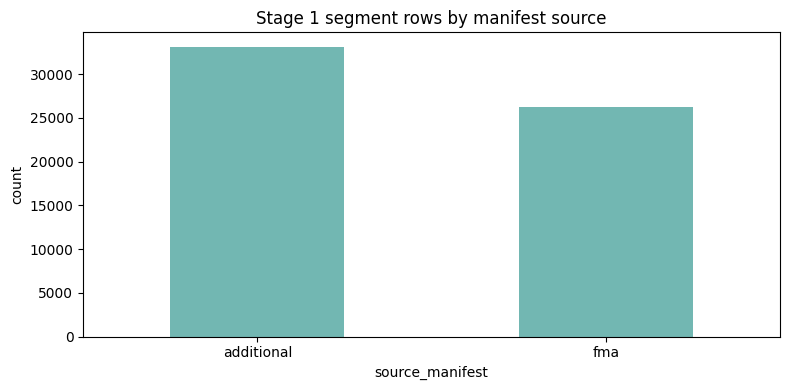

### Stage 1 Segment Rows by Source

,source,count
0,fma-medium,26204
1,my-collection,23228
2,mtg-jamendo,7815
3,gtzan,2097


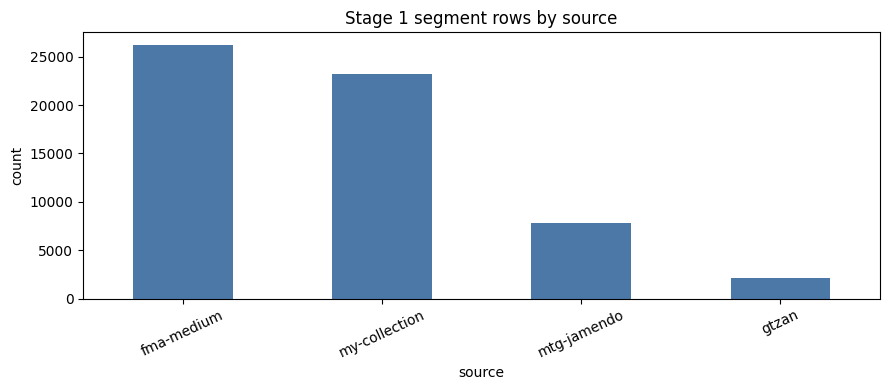

### Stage 1 Segment Rows by Genre

,genre_top,count,proportion_pct,imbalance_ratio_vs_max
0,Rock,20719,34.91,1.000
1,Hip-Hop,5934,10.00,3.492
2,Classical,4914,8.28,4.216
3,Jazz,4569,7.70,4.535
4,Pop,4455,7.51,4.651
5,Bolero,4386,7.39,4.724
6,Blues,4338,7.31,4.776
7,Speech,3654,6.16,5.670
8,Country,3360,5.66,6.166
9,Metal,3015,5.08,6.872


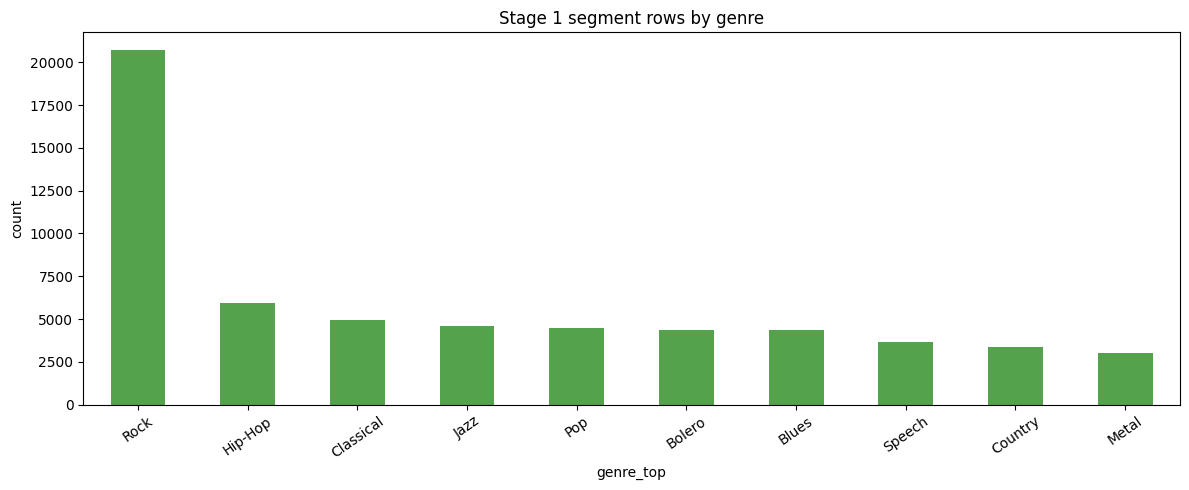

### Final Split Counts

,final_split,count
0,training,22277
1,validation,4776
2,test,4773


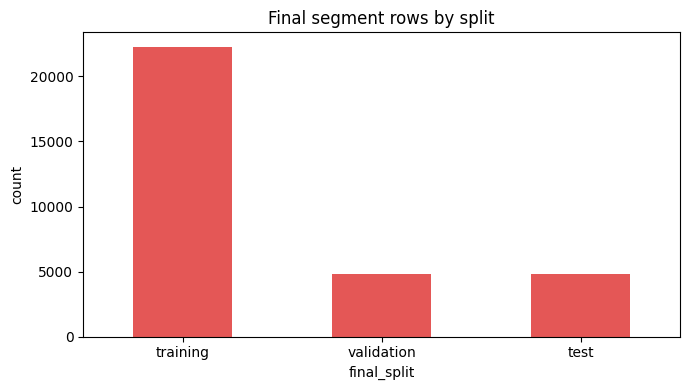

### Final Segment Rows by Genre

,genre_top,count,proportion_pct,imbalance_ratio_vs_max
0,Country,3204,10.07,1.000
1,Blues,3201,10.06,1.001
2,Bolero,3201,10.06,1.001
3,Classical,3201,10.06,1.001
4,Hip-Hop,3201,10.06,1.001
5,Jazz,3201,10.06,1.001
6,Pop,3201,10.06,1.001
7,Speech,3201,10.06,1.001
8,Rock,3200,10.05,1.001
9,Metal,3015,9.47,1.063


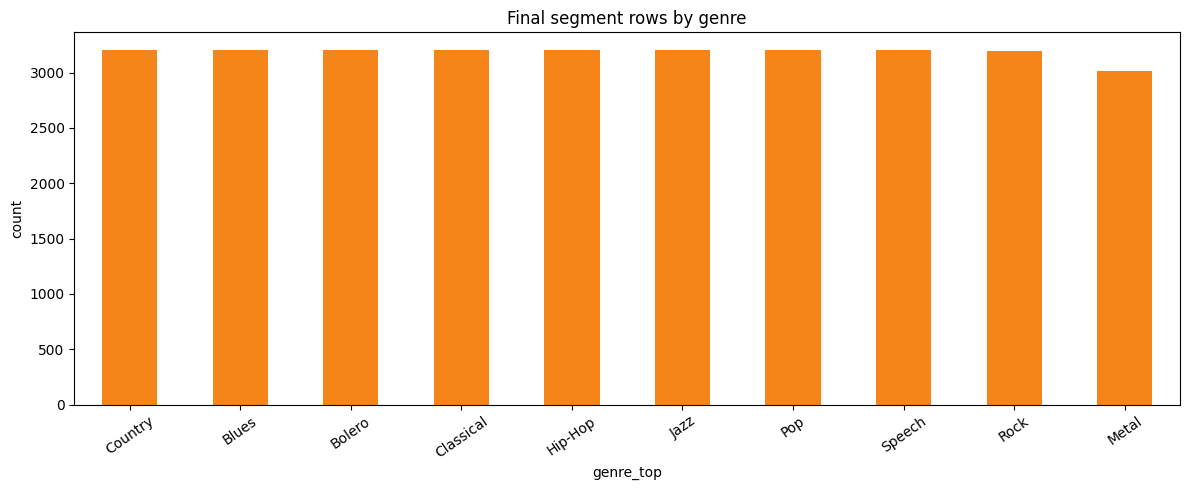

### Final Counts by Genre and Split

final_split,test,training,validation
genre_top,,,
Blues,480,2241,480
Bolero,480,2241,480
Classical,480,2241,480
Country,480,2241,483
Hip-Hop,480,2241,480
Jazz,480,2241,480
Metal,453,2109,453
Pop,480,2241,480
Rock,480,2240,480


final_split,test,training,validation
genre_top,,,
Blues,15.00,70.01,15.00
Bolero,15.00,70.01,15.00
Classical,15.00,70.01,15.00
Country,14.98,69.94,15.07
Hip-Hop,15.00,70.01,15.00
Jazz,15.00,70.01,15.00
Metal,15.02,69.95,15.02
Pop,15.00,70.01,15.00
Rock,15.00,70.00,15.00


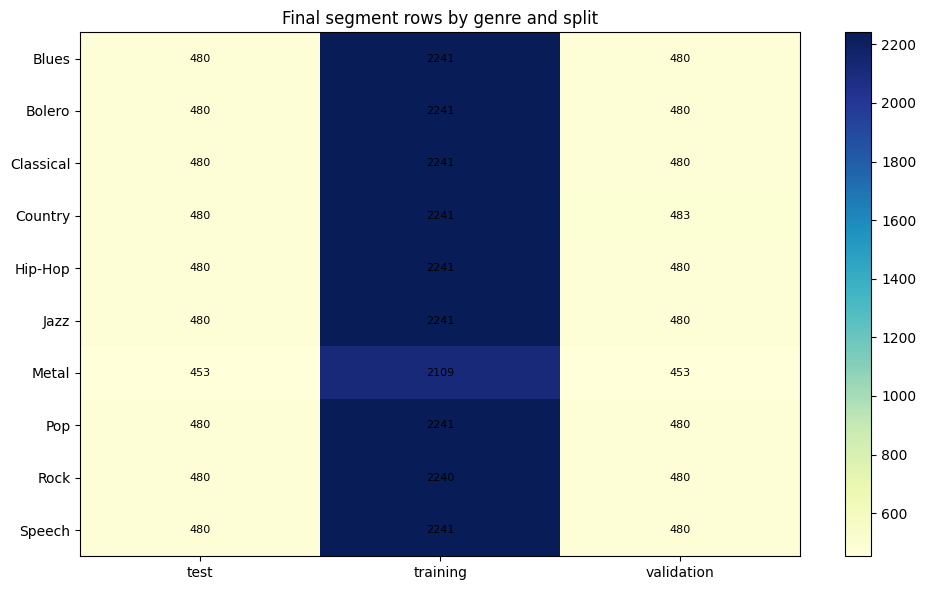

### Retention by Source

,stage1_artifacts,stage1_segments,final_segments,retained_ratio_pct
source,,,,
fma-medium,8735,26204,5154,19.67
gtzan,699,2097,1713,81.69
mtg-jamendo,2605,7815,6174,79.00
my-collection,7743,23228,18785,80.87


### Leakage-Safety Check

,metric,value
0,artifacts_in_multiple_final_splits,0


Leakage check passed: no source-audio artifact appears in more than one final split.


### Additional-Source Contribution

,metric,value
0,target_additional_contribution_pct,70.00
1,actual_additional_contribution_pct,83.81
2,actual_fma_contribution_pct,16.19


source_family,fma,additional_datasets
genre_top,,
Blues,222,2979
Bolero,0,3201
Classical,960,2241
Country,534,2670
Hip-Hop,960,2241
Jazz,960,2241
Metal,0,3015
Pop,558,2643
Rock,960,2240


source_family,fma,additional_datasets,target_additional_pct,gap_vs_target_pct
genre_top,,,,
Blues,6.94,93.06,70.0,23.06
Bolero,0.00,100.00,70.0,30.00
Classical,29.99,70.01,70.0,0.01
Country,16.67,83.33,70.0,13.33
Hip-Hop,29.99,70.01,70.0,0.01
Jazz,29.99,70.01,70.0,0.01
Metal,0.00,100.00,70.0,30.00
Pop,17.43,82.57,70.0,12.57
Rock,30.00,70.00,70.0,0.00


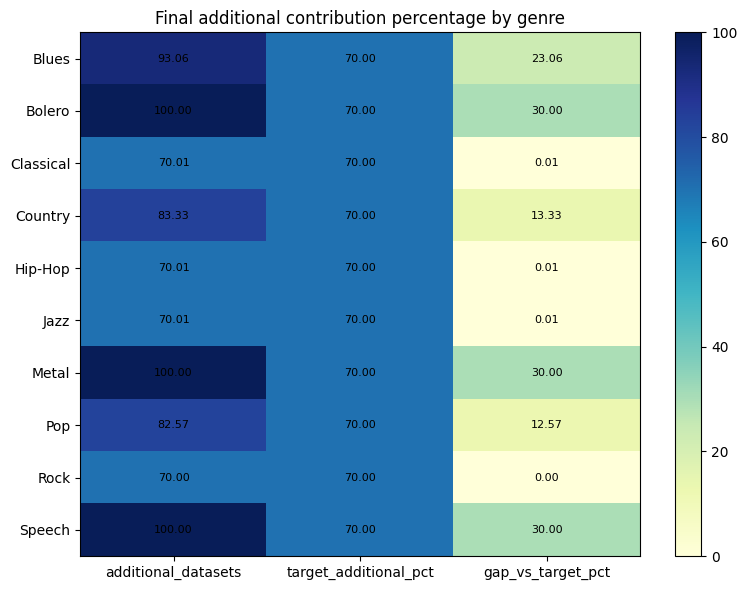

In [6]:
all_samples_audio_summary = all_samples_df.groupby('artifact_id').agg(
    source=('source', 'first'),
    genre_top=('genre_top', 'first'),
    duration_s=('duration_s', 'first'),
    actual_duration_s=('actual_duration_s', 'first'),
    total_segments_from_audio=('total_segments_from_audio', 'first'),
    emitted_segments=('sample_id', 'size'),
).reset_index()

final_samples_audio_level = final_samples_df.copy()
final_samples_audio_level['artifact_id'] = final_samples_audio_level['sample_id'].map(artifact_id_from_sample_id)
final_samples_audio_summary = final_samples_audio_level.groupby('artifact_id').agg(
    source=('source', 'first'),
    genre_top=('genre_top', 'first'),
    final_split=('final_split', 'first'),
    selected_segments=('sample_id', 'size'),
).reset_index()

segment_transition_df = all_samples_audio_summary.merge(
    final_samples_audio_summary[['artifact_id', 'final_split', 'selected_segments']],
    on='artifact_id',
    how='left',
)
segment_transition_df['selected_segments'] = segment_transition_df['selected_segments'].fillna(0).astype(int)
segment_transition_df['retained_ratio_pct'] = (segment_transition_df['selected_segments'] / segment_transition_df['emitted_segments']).mul(100).round(2)

transition_summary = pd.DataFrame([
    {'metric': 'all_stage1_sample_rows', 'value': len(all_samples_df)},
    {'metric': 'final_sample_rows', 'value': len(final_samples_df)},
    {'metric': 'unique_stage1_artifacts', 'value': len(all_samples_audio_summary)},
    {'metric': 'unique_final_artifacts', 'value': len(final_samples_audio_summary)},
    {'metric': 'mean_emitted_segments_per_audio', 'value': round(all_samples_audio_summary['emitted_segments'].mean(), 2)},
    {'metric': 'mean_selected_segments_per_audio', 'value': round(final_samples_audio_summary['selected_segments'].mean(), 2)},
])
display(transition_summary)

stage1_segments_by_manifest = all_samples_df['_source_manifest'].value_counts()
stage1_segments_by_source = all_samples_df['source'].value_counts()
stage1_segments_by_genre = all_samples_df['genre_top'].value_counts()
final_split_counts = final_samples_df['final_split'].value_counts()
final_genre_counts = final_samples_df['genre_top'].value_counts()
genre_split_table = pd.crosstab(final_samples_df['genre_top'], final_samples_df['final_split'])
genre_split_pct = genre_split_table.div(genre_split_table.sum(axis=1), axis=0).mul(100).round(2)

retention_by_source = segment_transition_df.groupby('source').agg(
    stage1_artifacts=('artifact_id', 'size'),
    stage1_segments=('emitted_segments', 'sum'),
    final_segments=('selected_segments', 'sum'),
)
retention_by_source['retained_ratio_pct'] = (retention_by_source['final_segments'] / retention_by_source['stage1_segments']).mul(100).round(2)

display(Markdown('### Stage 1 Segment Rows by Manifest'))
display(stage1_segments_by_manifest.rename_axis('source_manifest').reset_index(name='count'))
plot_bar(stage1_segments_by_manifest, title='Stage 1 segment rows by manifest source', xlabel='source_manifest', rotation=0, figsize=(8, 4), color='#72B7B2')

display(Markdown('### Stage 1 Segment Rows by Source'))
display(stage1_segments_by_source.rename_axis('source').reset_index(name='count'))
plot_bar(stage1_segments_by_source, title='Stage 1 segment rows by source', xlabel='source', rotation=25, figsize=(9, 4), color='#4C78A8')

display(Markdown('### Stage 1 Segment Rows by Genre'))
display(imbalance_table(all_samples_df['genre_top'], name='genre_top'))
plot_bar(stage1_segments_by_genre, title='Stage 1 segment rows by genre', xlabel='genre_top', rotation=35, figsize=(12, 5), color='#54A24B')

display(Markdown('### Final Split Counts'))
display(final_split_counts.rename_axis('final_split').reset_index(name='count'))
plot_bar(final_split_counts, title='Final segment rows by split', xlabel='final_split', rotation=0, figsize=(7, 4), color='#E45756')

display(Markdown('### Final Segment Rows by Genre'))
display(imbalance_table(final_samples_df['genre_top'], name='genre_top'))
plot_bar(final_genre_counts, title='Final segment rows by genre', xlabel='genre_top', rotation=35, figsize=(12, 5), color='#F58518')

display(Markdown('### Final Counts by Genre and Split'))
display(genre_split_table)
display(genre_split_pct)
plot_heatmap(genre_split_table.astype(float), title='Final segment rows by genre and split', figsize=(10, 6), fmt='.0f')

display(Markdown('### Retention by Source'))
display(retention_by_source)

artifact_split_counts = final_samples_audio_level.groupby('artifact_id')['final_split'].nunique()
leakage_artifacts = artifact_split_counts[artifact_split_counts > 1]
leakage_count = int(leakage_artifacts.shape[0])
display(Markdown('### Leakage-Safety Check'))
display(pd.DataFrame([{'metric': 'artifacts_in_multiple_final_splits', 'value': leakage_count}]))
if leakage_count == 0:
    print('Leakage check passed: no source-audio artifact appears in more than one final split.')
else:
    display(leakage_artifacts.rename('num_splits').reset_index())

final_samples_source_view = final_samples_df.copy()
final_samples_source_view['source_family'] = np.where(
    final_samples_source_view['source'].astype(str).str.casefold().str.startswith('fma'),
    'fma',
    'additional_datasets',
)
additional_ratio_target_pct = round(float(sampling_settings.get('additional_samples_contribution_ratio_expected_each_genre', 0.0)) * 100, 2)
overall_source_counts = final_samples_source_view['source_family'].value_counts().reindex(['fma', 'additional_datasets'], fill_value=0)
overall_additional_share_pct = round(overall_source_counts.get('additional_datasets', 0) / max(len(final_samples_source_view), 1) * 100, 2)
genre_source_table = pd.crosstab(final_samples_source_view['genre_top'], final_samples_source_view['source_family']).reindex(columns=['fma', 'additional_datasets'], fill_value=0)
genre_source_pct = genre_source_table.div(genre_source_table.sum(axis=1), axis=0).mul(100).round(2)
genre_source_pct['target_additional_pct'] = additional_ratio_target_pct
genre_source_pct['gap_vs_target_pct'] = (genre_source_pct['additional_datasets'] - genre_source_pct['target_additional_pct']).round(2)

display(Markdown('### Additional-Source Contribution'))
display(pd.DataFrame([
    {'metric': 'target_additional_contribution_pct', 'value': additional_ratio_target_pct},
    {'metric': 'actual_additional_contribution_pct', 'value': overall_additional_share_pct},
    {'metric': 'actual_fma_contribution_pct', 'value': round(100 - overall_additional_share_pct, 2)},
]))
display(genre_source_table)
display(genre_source_pct)
plot_heatmap(genre_source_pct[['additional_datasets', 'target_additional_pct', 'gap_vs_target_pct']].astype(float), title='Final additional contribution percentage by genre', figsize=(8, 6), fmt='.2f')

## Supplementation-Aware Small-Split Audit

After auditing the generic final manifest, this section narrows to the small-dataset workflow where official FMA membership, live processed split parquets, and staged supplementation payloads can diverge.

That distinction matters because `extra_samples_for_small_dataset.json` may already describe candidate supplementation while the current `train_small`, `val_small`, and `test_small` parquet files may still reflect the unsupplemented state.

This section answers four practical questions when the small workflow is active:

1. What does the official exact FMA-small split look like?
2. What do the current processed `train_small`, `val_small`, and `test_small` parquet files contain right now?
3. Have the live processed small splits already diverged from official exact-small through non-FMA or supplementation-driven rows?
4. What payload is currently staged in `extra_samples_for_small_dataset.json` by genre and source?

If those artifacts are missing, this section skips cleanly and the broader manifest audit still remains valid.

In [7]:
supplementation_audit_ready = False
official_small_df = None
processed_small_df = None
official_small_counts = pd.DataFrame()
processed_small_counts = pd.DataFrame()
processed_small_source_summary = pd.DataFrame()
payload_source_summary = pd.DataFrame()
payload_genre_source_summary = pd.DataFrame()
payload_allocation_summary = pd.DataFrame()
supplementation_metrics_table = pd.DataFrame()
current_has_non_fma_rows = False
selected_payload_rows = 0
official_current_row_delta = 0
new_genres_vs_official_small = []


def stable_row_key(row: dict[str, object]) -> str:
    track_id = row.get('track_id')
    filepath = row.get('filepath') or row.get('relative_path') or row.get('filename') or ''
    return '|'.join([
        str(row.get('source') or ''),
        str(row.get('genre') or row.get('genre_top') or ''),
        '' if track_id is None else str(track_id),
        str(filepath),
    ])


def genre_seed(base_seed: int, genre: str) -> int:
    digest = hashlib.sha1(genre.encode('utf-8')).digest()
    genre_hash = int.from_bytes(digest[:4], byteorder='big', signed=False)
    return base_seed + genre_hash


def deterministic_shuffle(rows: list[dict[str, object]], seed: int, genre: str) -> list[dict[str, object]]:
    shuffled = list(rows)
    shuffled.sort(key=stable_row_key)
    random.Random(genre_seed(seed, genre)).shuffle(shuffled)
    return shuffled


def compute_split_counts(total: int, train_ratio: float) -> dict[str, int]:
    train_count = int(round(total * train_ratio))
    train_count = max(0, min(total, train_count))

    remainder = total - train_count
    if remainder % 2 == 1:
        train_count += 1
        remainder -= 1

    val_count = remainder // 2
    test_count = remainder // 2
    return {
        'training': train_count,
        'validation': val_count,
        'test': test_count,
    }


def counts_by_genre_and_split(frame: pd.DataFrame) -> pd.DataFrame:
    table = pd.crosstab(frame['genre_top'], frame['split'])
    return table.reindex(columns=SUPPLEMENTED_SPLIT_ORDER, fill_value=0).sort_index()


def proportions_from_counts(counts: pd.DataFrame) -> pd.DataFrame:
    return counts.div(counts.sum(axis=0), axis=1).fillna(0.0)


def tvd(p: np.ndarray, q: np.ndarray) -> float:
    return 0.5 * np.abs(p - q).sum()


def jsd(p: np.ndarray, q: np.ndarray, eps: float = 1e-12) -> float:
    p = np.clip(p, eps, 1.0)
    p = p / p.sum()
    q = np.clip(q, eps, 1.0)
    q = q / q.sum()
    m = 0.5 * (p + q)
    return 0.5 * (np.sum(p * np.log2(p / m)) + np.sum(q * np.log2(q / m)))


def split_distance_metrics(counts: pd.DataFrame) -> dict[str, float]:
    props = proportions_from_counts(counts)
    genres = props.index
    p_train = props['training'].reindex(genres).to_numpy()
    p_val = props['validation'].reindex(genres).to_numpy()
    p_test = props['test'].reindex(genres).to_numpy()
    return {
        'TVD(train,val)': tvd(p_train, p_val),
        'TVD(train,test)': tvd(p_train, p_test),
        'JSD(train,val)': jsd(p_train, p_val),
        'JSD(train,test)': jsd(p_train, p_test),
    }


def add_all_column(counts: pd.DataFrame) -> pd.DataFrame:
    table = counts.reindex(columns=SUPPLEMENTED_SPLIT_ORDER, fill_value=0).astype(int).copy()
    table['all'] = table.sum(axis=1)
    return table.sort_values('all', ascending=False)


small_split_paths_exist = all((PROCESSED_DIR / filename).exists() for filename in SUPPLEMENTED_SPLIT_FILES.values())
extra_samples_exists = EXTRA_SAMPLES_PATH.exists()
tracks_csv_exists = TRACKS_CSV.exists()

if tracks_csv_exists and small_split_paths_exist:
    tracks = pd.read_csv(TRACKS_CSV, header=[0, 1], index_col=0)
    official_mask = (
        (tracks[('set', 'subset')] == SUPPLEMENTED_TARGET_SUBSET)
        & tracks[('track', 'genre_top')].notna()
        & tracks[('set', 'split')].isin(SUPPLEMENTED_SPLIT_ORDER)
    )
    official_small_df = tracks.loc[official_mask, [('set', 'split'), ('track', 'genre_top')]].copy()
    official_small_df.columns = ['split', 'genre_top']
    official_small_df['source'] = 'fma'
    official_small_df['sample_id'] = official_small_df.index.map(lambda track_id: f'fma:{int(track_id)}')
    official_small_df.index.name = 'track_id'

    processed_small_frames = []
    for split_name, filename in SUPPLEMENTED_SPLIT_FILES.items():
        split_path = PROCESSED_DIR / filename
        frame = pd.read_parquet(split_path).copy()
        frame['split'] = split_name
        frame.index.name = 'track_id'
        processed_small_frames.append(frame)
    processed_small_df = pd.concat(processed_small_frames, axis=0)

    official_small_counts = counts_by_genre_and_split(official_small_df)
    processed_small_counts = counts_by_genre_and_split(processed_small_df)

    official_split_sizes = official_small_df['split'].value_counts().reindex(SUPPLEMENTED_SPLIT_ORDER, fill_value=0)
    processed_split_sizes = processed_small_df['split'].value_counts().reindex(SUPPLEMENTED_SPLIT_ORDER, fill_value=0)
    split_size_compare = pd.concat(
        [
            official_split_sizes.rename('official_exact_small'),
            processed_split_sizes.rename('processed_current'),
        ],
        axis=1,
    )
    split_size_compare['delta_vs_official'] = split_size_compare['processed_current'] - split_size_compare['official_exact_small']

    processed_small_source_summary = (
        processed_small_df.groupby(['split', 'source']).size().unstack(fill_value=0).reindex(SUPPLEMENTED_SPLIT_ORDER, fill_value=0)
    )

    current_has_non_fma_rows = 'source' in processed_small_df.columns and processed_small_df['source'].astype(str).ne('fma').any()
    new_genres_vs_official_small = sorted(set(processed_small_counts.index) - set(official_small_counts.index))
    official_current_row_delta = int(processed_small_df.shape[0] - official_small_df.shape[0])

    display(Markdown('### Official Exact-Small vs Current Processed Small Splits'))
    display(split_size_compare)
    display(Markdown('### Current Processed Small Source Mix by Split'))
    display(processed_small_source_summary)
    print(f'Non-FMA rows already present in processed small splits? {current_has_non_fma_rows}')
    print(f'Genres outside official exact-small currently present: {new_genres_vs_official_small}')

    display(Markdown('### Official Exact-Small Genre Counts'))
    display(official_small_counts)
    display(Markdown('### Current Processed Small Genre Counts'))
    display(processed_small_counts)

    fig, axes = plt.subplots(1, 3, figsize=(22, 5))
    pd.DataFrame({
        'official': official_split_sizes,
        'current': processed_split_sizes,
    }).plot(kind='bar', ax=axes[0], width=0.75)
    axes[0].set_title('Split sizes: official vs current small')
    axes[0].set_ylabel('Rows')
    axes[0].tick_params(axis='x', rotation=0)

    top_genres = (
        processed_small_counts.sum(axis=1)
        .add(official_small_counts.sum(axis=1), fill_value=0)
        .sort_values(ascending=False)
        .head(12)
        .index
    )
    training_compare = pd.DataFrame({
        'official_training': official_small_counts['training'].reindex(top_genres, fill_value=0),
        'current_training': processed_small_counts['training'].reindex(top_genres, fill_value=0),
    })
    training_compare.plot(kind='bar', ax=axes[1], width=0.8)
    axes[1].set_title('Training split genre counts (top 12)')
    axes[1].set_ylabel('Rows')
    axes[1].tick_params(axis='x', rotation=55)

    if not processed_small_source_summary.empty:
        processed_small_source_summary.plot(kind='bar', stacked=True, ax=axes[2], width=0.75)
        axes[2].set_title('Current processed small source mix by split')
        axes[2].set_ylabel('Rows')
        axes[2].tick_params(axis='x', rotation=0)
    plt.tight_layout()
    plt.show()

    supplementation_metrics_table = pd.DataFrame({
        'official_exact_small': split_distance_metrics(official_small_counts),
        'processed_current': split_distance_metrics(processed_small_counts),
    }).T.round(4)
    display(Markdown('### Split-Distance Metrics'))
    display(supplementation_metrics_table)

if extra_samples_exists and settings_payload is not None:
    extra_samples_payload = json.loads(EXTRA_SAMPLES_PATH.read_text())
    supplementation_settings = settings_payload.get('small_dataset_supplementation', {})
    target_genres = supplementation_settings.get('target_genres', [])
    n_extra_expected = int(supplementation_settings.get('n_extra_expected', 0) or 0)
    train_ratio = float(supplementation_settings.get('train_n_val_test_split_ratio', 0.8) or 0.8)
    selected_tracks = extra_samples_payload.get('selected_tracks', {})

    allocation_records = []
    allocation_summary_records = []
    for genre in target_genres:
        genre_rows = list(selected_tracks.get(genre, []))[:n_extra_expected]
        shuffled_rows = deterministic_shuffle(genre_rows, SUPPLEMENTATION_BASE_RANDOM_SEED, genre)
        split_counts = compute_split_counts(len(shuffled_rows), train_ratio)

        for row in shuffled_rows:
            allocation_records.append({
                'genre_top': genre,
                'source': row.get('source', 'unknown'),
                'track_id': row.get('track_id'),
                'filepath': row.get('filepath'),
            })

        allocation_summary_records.append({
            'genre_top': genre,
            'selected_rows_used': len(shuffled_rows),
            'cap_per_genre': n_extra_expected,
            'train_would_get': split_counts['training'],
            'validation_would_get': split_counts['validation'],
            'test_would_get': split_counts['test'],
        })

    allocation_df = pd.DataFrame(allocation_records)
    payload_allocation_summary = pd.DataFrame(allocation_summary_records).set_index('genre_top').sort_values('selected_rows_used', ascending=False)
    selected_payload_rows = int(len(allocation_df))

    display(Markdown('### Supplementation Payload Allocation Summary'))
    display(payload_allocation_summary)

    if allocation_df.empty:
        print('No selected supplementation rows were found in extra_samples_for_small_dataset.json.')
    else:
        payload_source_summary = (
            allocation_df.groupby('source').size().rename('selected_rows').sort_values(ascending=False).to_frame()
        )
        payload_genre_source_summary = (
            allocation_df.groupby(['genre_top', 'source']).size().unstack(fill_value=0).sort_index()
        )
        display(Markdown('### Supplementation Payload Source Mix'))
        display(payload_source_summary)
        display(Markdown('### Supplementation Payload Rows by Genre and Source'))
        display(payload_genre_source_summary)

        fig, axes = plt.subplots(1, 2, figsize=(18, 5))
        payload_allocation_summary['selected_rows_used'].sort_values(ascending=False).plot(kind='bar', ax=axes[0], color='#4C78A8')
        axes[0].set_title('Selected supplementation payload rows per target genre')
        axes[0].set_ylabel('Rows')
        axes[0].tick_params(axis='x', rotation=55)

        payload_source_summary['selected_rows'].plot(kind='bar', ax=axes[1], color='#F58518')
        axes[1].set_title('Supplementation payload source mix')
        axes[1].set_ylabel('Rows')
        axes[1].tick_params(axis='x', rotation=35)
        plt.tight_layout()
        plt.show()

supplementation_audit_ready = tracks_csv_exists and small_split_paths_exist
if not supplementation_audit_ready:
    print('Supplementation-aware small-split audit is skipped because official small metadata or processed small split parquet files are missing.')
if not extra_samples_exists:
    print('No extra_samples_for_small_dataset.json found; payload provenance portion of the supplementation-aware audit is unavailable.')

Supplementation-aware small-split audit is skipped because official small metadata or processed small split parquet files are missing.
No extra_samples_for_small_dataset.json found; payload provenance portion of the supplementation-aware audit is unavailable.


## Downstream Log-Mel, TFRecord, and Training Audit

This final section checks the handoff from the selected final manifest into three downstream stages:

1. log-mel materialization by `2_build_log_mel_dataset.py`
2. TFRecord conversion by `3_convert_npy_2_tfrecord.py`
3. the latest saved training run metadata from `logmel_cnn_v2_4_1_cuda_tf.py`

The manifest layer remains the required audit boundary, but after your latest run the downstream artifacts are present and should be checked directly.

,artifact,exists
0,logmel_config.json,True
1,logmel_manifest_all.parquet,True
2,logmel_manifest_train.parquet,True
3,logmel_manifest_val.parquet,True
4,logmel_manifest_test.parquet,True
5,tfrecord_config.json,True
6,tfrecord_manifest_all.parquet,True
7,tfrecord_manifest_train.parquet,True
8,tfrecord_manifest_val.parquet,True
9,tfrecord_manifest_test.parquet,True


### logmel_config.json

,key,value
0,manifest,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/data/processed/manifest_final_samples.parquet
1,settings,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/settings.json
2,out_root,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s
3,rows_requested,31826
4,target_genres,"[""Hip-Hop"", ""Pop"", ""Rock"", ""Metal"", ""Classical"", ""Jazz"", ""Country"", ""Blues"", ""Bolero"", ""Speech""]"
5,sample_rate,22050
6,sample_length_sec,10.0
7,n_mels,128
8,n_fft,512
9,hop_length,256


### tfrecord_config.json

,key,value
0,source_logmel_root,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s
1,out_root,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord
2,generated_at,2026-03-20T02:09:36Z
3,records_per_shard,1024
4,compression,none
5,sample_rate,22050
6,sample_length_sec,10.0
7,n_mels,128
8,n_fft,512
9,hop_length,256


...

,sample_id,source,genre_top,filepath,track_id,sample_length_sec,segment_index,segment_start_sec,segment_end_sec,total_segments_from_audio,duration_s,actual_duration_s,reason_code,final_split,split_dir,logmel_path,logmel_relpath,logmel_status,logmel_reason,logmel_usable,logmel_shape,sample_rate,n_mels,n_fft,hop_length
0,006e4f445a7d6a4aefedb5c9093e2f39:seg0000,my-collection,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/my-collection/blues/Bourbon Blues__seg06_start420.13s.wav,<NA>,10.0,0,0.0,10.0,3,31.0,31.0,OK,test,test,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s/test/Blues/300d7c4bc66f0957949e.npy,test/Blues/300d7c4bc66f0957949e.npy,ok,,True,128x861,22050,128,512,256
1,006e4f445a7d6a4aefedb5c9093e2f39:seg0001,my-collection,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/my-collection/blues/Bourbon Blues__seg06_start420.13s.wav,<NA>,10.0,1,10.0,20.0,3,31.0,31.0,OK,test,test,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s/test/Blues/cf873c5c4b84d54ddb4e.npy,test/Blues/cf873c5c4b84d54ddb4e.npy,ok,,True,128x861,22050,128,512,256
2,006e4f445a7d6a4aefedb5c9093e2f39:seg0002,my-collection,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/my-collection/blues/Bourbon Blues__seg06_start420.13s.wav,<NA>,10.0,2,20.0,30.0,3,31.0,31.0,OK,test,test,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s/test/Blues/a777b0f0945e2b630ecd.npy,test/Blues/a777b0f0945e2b630ecd.npy,ok,,True,128x861,22050,128,512,256
3,01651ad200808ecf077d90061b54794b:seg0000,mtg-jamendo,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/mtg-jamendo/blues/1219560__seg02_start057.26s.wav,<NA>,10.0,0,0.0,10.0,3,31.0,31.0,OK,test,test,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s/test/Blues/a6d09a88b9e799df14e6.npy,test/Blues/a6d09a88b9e799df14e6.npy,ok,,True,128x861,22050,128,512,256
4,01651ad200808ecf077d90061b54794b:seg0001,mtg-jamendo,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/mtg-jamendo/blues/1219560__seg02_start057.26s.wav,<NA>,10.0,1,10.0,20.0,3,31.0,31.0,OK,test,test,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s/test/Blues/4d709772af90881595f1.npy,test/Blues/4d709772af90881595f1.npy,ok,,True,128x861,22050,128,512,256


,column,dtype,null_count,null_pct
0,sample_id,object,0,0.00
1,source,object,0,0.00
2,genre_top,object,0,0.00
3,filepath,object,0,0.00
4,track_id,Int64,26672,83.81
5,sample_length_sec,float64,0,0.00
6,segment_index,int64,0,0.00
7,segment_start_sec,float64,0,0.00
8,segment_end_sec,float64,0,0.00
9,total_segments_from_audio,Int64,0,0.00


### Log-Mel Summary

,metric,value
0,logmel_manifest_all_rows,31826
1,logmel_manifest_train_rows,21721
2,logmel_manifest_val_rows,4637
3,logmel_manifest_test_rows,4660
4,usable_logmels_all,31018
5,missing_logmels_all,808


,split_dir,count
0,test,4773
1,train,22277
2,val,4776


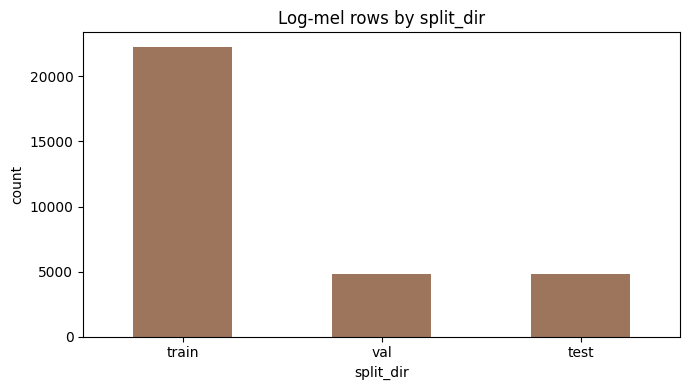

,logmel_status,count
0,ok,31018
1,skipped,808


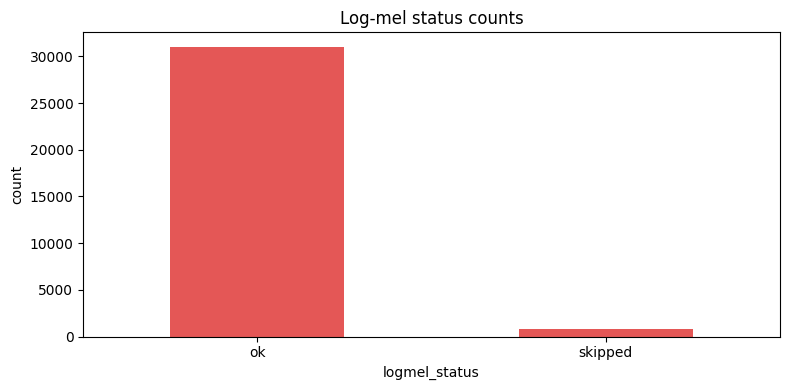

### Final Manifest to Log-Mel Alignment

,metric,value
0,final_manifest_rows,31826
1,matched_logmel_rows,31826
2,missing_logmel_rows,0
3,matched_and_usable,31018


### tfrecord_manifest_all

shape = (31018, 32)


,sample_id,source,genre_top,filepath,track_id,sample_length_sec,segment_index,segment_start_sec,segment_end_sec,total_segments_from_audio,duration_s,actual_duration_s,reason_code,final_split,split_dir,logmel_path,logmel_relpath,logmel_status,logmel_reason,logmel_usable,logmel_shape,sample_rate,n_mels,n_fft,hop_length,label_int,tfrecord_path,tfrecord_relpath,shard_index,record_index_in_shard,tfrecord_status,tfrecord_reason
0,005ebf79a9c3fd965037dc3e1765bd80:seg0000,my-collection,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/my-collection/blues/Dark Blues__seg113_start3466.11s.wav,NaN,10.0,0,0.0,10.0,3,31.0,31.000000,OK,training,train,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s/train/Blues/e059795418b84922bffc.npy,train/Blues/e059795418b84922bffc.npy,ok,,True,128x861,22050,128,512,256,0,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord/train/train-00000-of-00022.tfrecord,train/train-00000-of-00022.tfrecord,0,0,ok,
1,005ebf79a9c3fd965037dc3e1765bd80:seg0001,my-collection,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/my-collection/blues/Dark Blues__seg113_start3466.11s.wav,NaN,10.0,1,10.0,20.0,3,31.0,31.000000,OK,training,train,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s/train/Blues/ef4b6cc2d661415ad7f8.npy,train/Blues/ef4b6cc2d661415ad7f8.npy,ok,,True,128x861,22050,128,512,256,0,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord/train/train-00000-of-00022.tfrecord,train/train-00000-of-00022.tfrecord,0,1,ok,
2,005ebf79a9c3fd965037dc3e1765bd80:seg0002,my-collection,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/additional_datasets/data/my-collection/blues/Dark Blues__seg113_start3466.11s.wav,NaN,10.0,2,20.0,30.0,3,31.0,31.000000,OK,training,train,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s/train/Blues/7b6b0db99008bbe65ef9.npy,train/Blues/7b6b0db99008bbe65ef9.npy,ok,,True,128x861,22050,128,512,256,0,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord/train/train-00000-of-00022.tfrecord,train/train-00000-of-00022.tfrecord,0,2,ok,
3,00b449675fb58557e79aa65e0ee2fc0a:seg0000,fma-medium,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_medium/038/038545.mp3,38545.0,10.0,0,0.0,10.0,3,30.0,30.014694,OK,training,train,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s/train/Blues/bae8d5760668a15087c0.npy,train/Blues/bae8d5760668a15087c0.npy,ok,,True,128x861,22050,128,512,256,0,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord/train/train-00000-of-00022.tfrecord,train/train-00000-of-00022.tfrecord,0,3,ok,
4,00b449675fb58557e79aa65e0ee2fc0a:seg0001,fma-medium,Blues,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/FMA/fma_medium/038/038545.mp3,38545.0,10.0,1,10.0,20.0,3,30.0,30.014694,OK,training,train,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s/train/Blues/8f94ebb8f55fe40b3dbe.npy,train/Blues/8f94ebb8f55fe40b3dbe.npy,ok,,True,128x861,22050,128,512,256,0,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord/train/train-00000-of-00022.tfrecord,train/train-00000-of-00022.tfrecord,0,4,ok,


,column,dtype,null_count,null_pct
0,sample_id,object,0,0.00
1,source,object,0,0.00
2,genre_top,object,0,0.00
3,filepath,object,0,0.00
4,track_id,float64,25991,83.79
5,sample_length_sec,float64,0,0.00
6,segment_index,int64,0,0.00
7,segment_start_sec,float64,0,0.00
8,segment_end_sec,float64,0,0.00
9,total_segments_from_audio,int64,0,0.00


### TFRecord Summary

,metric,value
0,tfrecord_manifest_all_rows,31018
1,tfrecord_manifest_train_rows,21721
2,tfrecord_manifest_val_rows,4637
3,tfrecord_manifest_test_rows,4660
4,label_int_unique,10


,tfrecord_status,count
0,ok,31018


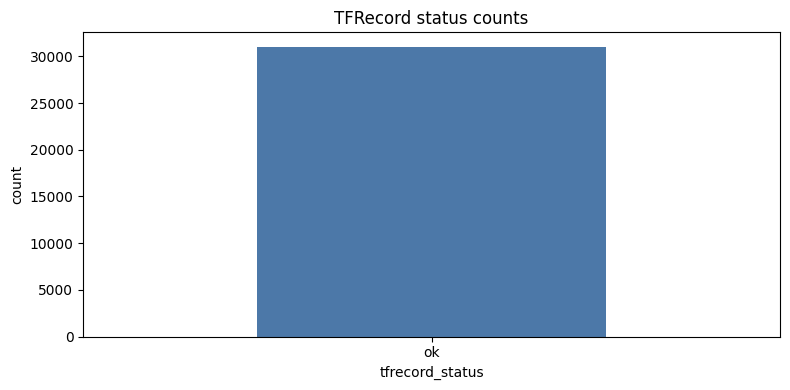

### tfrecord_shards_all

shape = (32, 5)


,split_dir,shard_index,records_in_shard,tfrecord_path,tfrecord_relpath
0,train,0,1024,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord/train/train-00000-of-00022.tfrecord,train/train-00000-of-00022.tfrecord
1,train,1,1024,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord/train/train-00001-of-00022.tfrecord,train/train-00001-of-00022.tfrecord
2,train,2,1024,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord/train/train-00002-of-00022.tfrecord,train/train-00002-of-00022.tfrecord
3,train,3,1024,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord/train/train-00003-of-00022.tfrecord,train/train-00003-of-00022.tfrecord
4,train,4,1024,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord/train/train-00004-of-00022.tfrecord,train/train-00004-of-00022.tfrecord


,column,dtype,null_count,null_pct
0,split_dir,object,0,0.0
1,shard_index,int64,0,0.0
2,records_in_shard,int64,0,0.0
3,tfrecord_path,object,0,0.0
4,tfrecord_relpath,object,0,0.0


,split_dir,records_in_shards
0,test,4660
1,train,21721
2,val,4637


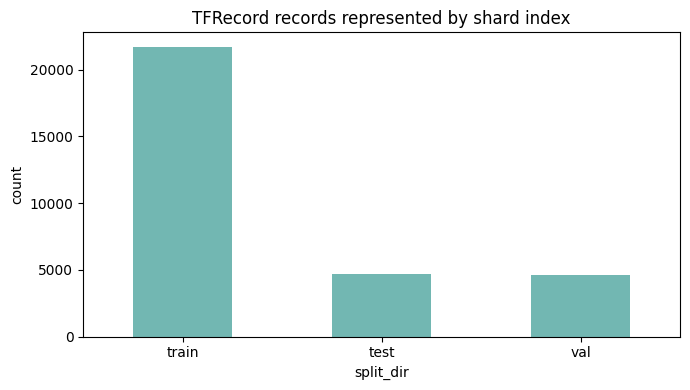

### Final Manifest to TFRecord Alignment

,metric,value
0,final_manifest_rows,31826
1,matched_tfrecord_rows,31018
2,missing_tfrecord_rows,808


,sample_id,genre_top,segment_index,segment_start_sec,sample_length_sec,final_split,split_dir,tfrecord_path,tfrecord_status,_merge
31,12caefec412a3f96d35180d69f9e5249:seg0001,Blues,1,10.0,10.0,test,NaN,NaN,NaN,left_only
120,4e0e7e5bdb69f64d4b62033631b8504a:seg0000,Blues,0,0.0,10.0,test,NaN,NaN,NaN,left_only
136,57b210470039a89568586552b9148898:seg0001,Blues,1,10.0,10.0,test,NaN,NaN,NaN,left_only
166,620c831408d89a245664dfb9b0fee7f3:seg0001,Blues,1,10.0,10.0,test,NaN,NaN,NaN,left_only
257,8ffe284e1faad49ab786d19be344d930:seg0002,Blues,2,20.0,10.0,test,NaN,NaN,NaN,left_only
309,a4f10047b0fdfb778fd9bc487ba4cd51:seg0000,Blues,0,0.0,10.0,test,NaN,NaN,NaN,left_only
344,b21088e987c0ee7667bb3f6ff1f9a07a:seg0002,Blues,2,20.0,10.0,test,NaN,NaN,NaN,left_only
355,b87c20830520f105aecedd5c20c59b65:seg0001,Blues,1,10.0,10.0,test,NaN,NaN,NaN,left_only
471,fa9955eadaa4a2aed9d949b1e8fd1963:seg0000,Blues,0,0.0,10.0,test,NaN,NaN,NaN,left_only
494,013fdc372506dc9f83cfa778ae240106:seg0002,Blues,2,20.0,10.0,training,NaN,NaN,NaN,left_only


### Latest Training Run Report

,key,value
0,run_id,logmel-cnn-v2_4-cuda-tf-20260320-033255
1,generated_at,2026-03-20 05:56:57
2,source_logmel_root,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s
3,tfrecord_dataset_dir,/home/hsnguyen/model-training-data-cache/logmel_dataset_10s_tfrecord


...

### Training dataset summary

,key,value
0,format,tfrecord
1,compression,none
2,n_classes,10
3,genres,"[""Blues"", ""Bolero"", ""Classical"", ""Country"", ""Hip-Hop"", ""Jazz"", ""Metal"", ""Pop"", ""Rock"", ""Speech""]"
4,train_samples,21721
5,val_samples,4637
6,test_samples,4660
7,train_shards,22
8,val_shards,5
9,test_shards,5


### Training normalization summary

,key,value
0,type,train_only_per_mel_bin_standardization
1,computed_from,train_split_only
2,epsilon,0.000001
3,stats_artifact,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/models/logmel-cnn-v2_4-cuda-tf-20260320-033255/norm_stats.npz
4,metadata_artifact,/mnt/d/mse/nguyen_sy_hung_codebases/machine-learning-1/MelCNN-MGR/models/logmel-cnn-v2_4-cuda-tf-20260320-033255/normalization_stats.json
5,mean_per_bin_shape,[128]
6,std_per_bin_shape,[128]
7,mean_per_bin_range,"[0.001153, 1.368359]"
8,std_per_bin_range,"[0.008661, 1.379733]"


,key,value
0,epochs_max,136
1,epochs_actual,89
2,batch_size,64
3,best_epoch_val_loss,88
4,best_epoch_macro_f1,80


In [8]:
downstream_presence_rows = [
    {'artifact': 'logmel_config.json', 'exists': LOGMEL_CONFIG_PATH is not None and LOGMEL_CONFIG_PATH.exists()},
    {'artifact': 'logmel_manifest_all.parquet', 'exists': LOGMEL_ALL_PATH is not None and LOGMEL_ALL_PATH.exists()},
    {'artifact': 'logmel_manifest_train.parquet', 'exists': LOGMEL_TRAIN_PATH is not None and LOGMEL_TRAIN_PATH.exists()},
    {'artifact': 'logmel_manifest_val.parquet', 'exists': LOGMEL_VAL_PATH is not None and LOGMEL_VAL_PATH.exists()},
    {'artifact': 'logmel_manifest_test.parquet', 'exists': LOGMEL_TEST_PATH is not None and LOGMEL_TEST_PATH.exists()},
    {'artifact': 'tfrecord_config.json', 'exists': TFRECORD_CONFIG_PATH is not None and TFRECORD_CONFIG_PATH.exists()},
    {'artifact': 'tfrecord_manifest_all.parquet', 'exists': TFRECORD_ALL_PATH is not None and TFRECORD_ALL_PATH.exists()},
    {'artifact': 'tfrecord_manifest_train.parquet', 'exists': TFRECORD_TRAIN_PATH is not None and TFRECORD_TRAIN_PATH.exists()},
    {'artifact': 'tfrecord_manifest_val.parquet', 'exists': TFRECORD_VAL_PATH is not None and TFRECORD_VAL_PATH.exists()},
    {'artifact': 'tfrecord_manifest_test.parquet', 'exists': TFRECORD_TEST_PATH is not None and TFRECORD_TEST_PATH.exists()},
    {'artifact': 'tfrecord_shards_all.parquet', 'exists': TFRECORD_SHARDS_ALL_PATH is not None and TFRECORD_SHARDS_ALL_PATH.exists()},
    {'artifact': 'latest_run_report', 'exists': LATEST_RUN_REPORT_PATH is not None and LATEST_RUN_REPORT_PATH.exists()},
]
display(pd.DataFrame(downstream_presence_rows))

display_json_table('logmel_config.json', logmel_config)
display_json_table('tfrecord_config.json', tfrecord_config)

if logmel_all_df is None:
    print('No logmel_manifest_all.parquet found under the detected log-mel root.')
else:
    display_frame_overview('logmel_manifest_all', logmel_all_df)
    logmel_summary = pd.DataFrame([
        {'metric': 'logmel_manifest_all_rows', 'value': len(logmel_all_df)},
        {'metric': 'logmel_manifest_train_rows', 'value': 0 if logmel_train_df is None else len(logmel_train_df)},
        {'metric': 'logmel_manifest_val_rows', 'value': 0 if logmel_val_df is None else len(logmel_val_df)},
        {'metric': 'logmel_manifest_test_rows', 'value': 0 if logmel_test_df is None else len(logmel_test_df)},
        {'metric': 'usable_logmels_all', 'value': int(logmel_all_df['logmel_usable'].sum()) if 'logmel_usable' in logmel_all_df.columns else None},
        {'metric': 'missing_logmels_all', 'value': int((~logmel_all_df['logmel_usable'].fillna(False)).sum()) if 'logmel_usable' in logmel_all_df.columns else None},
    ])
    display(Markdown('### Log-Mel Summary'))
    display(logmel_summary)

    split_dir_counts = logmel_all_df['split_dir'].value_counts().sort_index()
    display(split_dir_counts.rename_axis('split_dir').reset_index(name='count'))
    plot_bar(split_dir_counts, title='Log-mel rows by split_dir', xlabel='split_dir', rotation=0, figsize=(7, 4), color='#9D755D')

    if 'logmel_status' in logmel_all_df.columns:
        status_counts = logmel_all_df['logmel_status'].value_counts()
        display(status_counts.rename_axis('logmel_status').reset_index(name='count'))
        plot_bar(status_counts, title='Log-mel status counts', xlabel='logmel_status', rotation=0, figsize=(8, 4), color='#E45756')

    final_key_cols = ['sample_id', 'genre_top', 'segment_index', 'segment_start_sec', 'sample_length_sec']
    logmel_key_cols = ['sample_id', 'genre_top', 'segment_index', 'segment_start_sec', 'sample_length_sec']
    logmel_alignment = final_samples_df[final_key_cols + ['final_split']].merge(
        logmel_all_df[logmel_key_cols + ['split_dir', 'logmel_path', 'logmel_status', 'logmel_usable']],
        on=logmel_key_cols,
        how='left',
        indicator=True,
    )
    logmel_alignment_summary = pd.DataFrame([
        {'metric': 'final_manifest_rows', 'value': len(logmel_alignment)},
        {'metric': 'matched_logmel_rows', 'value': int((logmel_alignment['_merge'] == 'both').sum())},
        {'metric': 'missing_logmel_rows', 'value': int((logmel_alignment['_merge'] != 'both').sum())},
        {'metric': 'matched_and_usable', 'value': int(((logmel_alignment['_merge'] == 'both') & (logmel_alignment['logmel_usable'] == True)).sum())},
    ])
    display(Markdown('### Final Manifest to Log-Mel Alignment'))
    display(logmel_alignment_summary)
    if int((logmel_alignment['_merge'] != 'both').sum()) > 0:
        display(logmel_alignment[logmel_alignment['_merge'] != 'both'].head(20))

if tfrecord_all_df is None:
    print('No tfrecord_manifest_all.parquet found under the detected TFRecord root.')
else:
    display_frame_overview('tfrecord_manifest_all', tfrecord_all_df)
    tfrecord_summary = pd.DataFrame([
        {'metric': 'tfrecord_manifest_all_rows', 'value': len(tfrecord_all_df)},
        {'metric': 'tfrecord_manifest_train_rows', 'value': 0 if tfrecord_train_df is None else len(tfrecord_train_df)},
        {'metric': 'tfrecord_manifest_val_rows', 'value': 0 if tfrecord_val_df is None else len(tfrecord_val_df)},
        {'metric': 'tfrecord_manifest_test_rows', 'value': 0 if tfrecord_test_df is None else len(tfrecord_test_df)},
        {'metric': 'label_int_unique', 'value': int(tfrecord_all_df['label_int'].nunique()) if 'label_int' in tfrecord_all_df.columns else None},
    ])
    display(Markdown('### TFRecord Summary'))
    display(tfrecord_summary)

    if 'tfrecord_status' in tfrecord_all_df.columns:
        tfrecord_status_counts = tfrecord_all_df['tfrecord_status'].value_counts()
        display(tfrecord_status_counts.rename_axis('tfrecord_status').reset_index(name='count'))
        plot_bar(tfrecord_status_counts, title='TFRecord status counts', xlabel='tfrecord_status', rotation=0, figsize=(8, 4), color='#4C78A8')

    if tfrecord_shards_all_df is not None:
        display_frame_overview('tfrecord_shards_all', tfrecord_shards_all_df)
        shard_counts_by_split = tfrecord_shards_all_df.groupby('split_dir')['records_in_shard'].sum().sort_index()
        display(shard_counts_by_split.rename_axis('split_dir').reset_index(name='records_in_shards'))
        plot_bar(shard_counts_by_split, title='TFRecord records represented by shard index', xlabel='split_dir', rotation=0, figsize=(7, 4), color='#72B7B2')

    tfrecord_key_cols = ['sample_id', 'genre_top', 'segment_index', 'segment_start_sec', 'sample_length_sec']
    tfrecord_alignment = final_samples_df[tfrecord_key_cols + ['final_split']].merge(
        tfrecord_all_df[tfrecord_key_cols + ['split_dir', 'tfrecord_path', 'tfrecord_status']],
        on=tfrecord_key_cols,
        how='left',
        indicator=True,
    )
    tfrecord_alignment_summary = pd.DataFrame([
        {'metric': 'final_manifest_rows', 'value': len(tfrecord_alignment)},
        {'metric': 'matched_tfrecord_rows', 'value': int((tfrecord_alignment['_merge'] == 'both').sum())},
        {'metric': 'missing_tfrecord_rows', 'value': int((tfrecord_alignment['_merge'] != 'both').sum())},
    ])
    display(Markdown('### Final Manifest to TFRecord Alignment'))
    display(tfrecord_alignment_summary)
    if int((tfrecord_alignment['_merge'] != 'both').sum()) > 0:
        display(tfrecord_alignment[tfrecord_alignment['_merge'] != 'both'].head(20))

if isinstance(run_report, dict):
    display(Markdown('### Latest Training Run Report'))
    display(pd.DataFrame([
        {'key': 'run_id', 'value': run_report.get('run_id')},
        {'key': 'generated_at', 'value': run_report.get('generated_at')},
        {'key': 'source_logmel_root', 'value': run_report.get('source_logmel_root')},
        {'key': 'tfrecord_dataset_dir', 'value': run_report.get('tfrecord_dataset_dir')},
    ]))
    display_json_table('Training feature_config', run_report.get('feature_config'))
    display_json_table('Training dataset summary', run_report.get('dataset'))
    display_json_table('Training normalization summary', run_report.get('normalization'))
    if isinstance(run_report.get('training'), dict):
        training_summary = run_report['training']
        display(pd.DataFrame([
            {'key': 'epochs_max', 'value': training_summary.get('epochs_max')},
            {'key': 'epochs_actual', 'value': training_summary.get('epochs_actual')},
            {'key': 'batch_size', 'value': training_summary.get('batch_size')},
            {'key': 'best_epoch_val_loss', 'value': training_summary.get('best_epoch_val_loss')},
            {'key': 'best_epoch_macro_f1', 'value': training_summary.get('best_epoch_macro_f1')},
        ]))

In [9]:
final_split_counts = final_samples_df['final_split'].value_counts()
smallest_final_genre = final_samples_df['genre_top'].value_counts().idxmin() if not final_samples_df.empty else 'N/A'
dominant_file_genre = all_datasets_df['genre_top'].value_counts().idxmax() if not all_datasets_df.empty else 'N/A'
top_reason_code = all_datasets_df['reason_code'].value_counts().idxmax() if not all_datasets_df.empty else 'N/A'
mean_emitted_segments = round(all_samples_audio_summary['emitted_segments'].mean(), 2) if not all_samples_audio_summary.empty else 0
training_share_pct = round(final_split_counts.get('training', 0) / max(len(final_samples_df), 1) * 100, 2)
mean_genre_additional_gap_pct = round(genre_source_pct['gap_vs_target_pct'].abs().mean(), 2) if 'genre_source_pct' in globals() and not genre_source_pct.empty else 0

logmel_ready = logmel_all_df is not None
tfrecord_ready = tfrecord_all_df is not None
training_report_ready = isinstance(run_report, dict)
logmel_alignment_rate_pct = round(100 * int((logmel_alignment['_merge'] == 'both').sum()) / max(len(logmel_alignment), 1), 2) if 'logmel_alignment' in globals() else 0
tfrecord_alignment_rate_pct = round(100 * int((tfrecord_alignment['_merge'] == 'both').sum()) / max(len(tfrecord_alignment), 1), 2) if 'tfrecord_alignment' in globals() else 0
latest_run_id = run_report.get('run_id') if isinstance(run_report, dict) else 'N/A'
latest_feature_shape = run_report.get('feature_config', {}).get('logmel_shape') if isinstance(run_report, dict) else 'N/A'
latest_train_samples = run_report.get('dataset', {}).get('train_samples') if isinstance(run_report, dict) else 'N/A'
latest_val_samples = run_report.get('dataset', {}).get('val_samples') if isinstance(run_report, dict) else 'N/A'
latest_test_samples = run_report.get('dataset', {}).get('test_samples') if isinstance(run_report, dict) else 'N/A'

supplementation_status = 'available' if supplementation_audit_ready else 'not available'
supplementation_non_fma_state = current_has_non_fma_rows if supplementation_audit_ready else 'unknown'
supplementation_payload_rows = selected_payload_rows if 'selected_payload_rows' in globals() else 0
supplementation_official_delta = official_current_row_delta if supplementation_audit_ready else 'unknown'
supplementation_new_genres = new_genres_vs_official_small if supplementation_audit_ready else []

summary_markdown = f'''
## Key Findings and Readiness Summary

This closing summary reflects the full audit path: stage 1 discovery, source-specific sample expansion, stage 2 final split selection, optional small-split supplementation state, log-mel materialization, TFRecord conversion, and latest training-run metadata.

1. The file-level discovered dataset is currently dominated by **{dominant_file_genre}**.
2. The most frequent file-level reason code is **{top_reason_code}**.
3. The stage 1 segment-expansion outputs emit an average of **{mean_emitted_segments}** segments per source audio that produced samples.
4. The final manifest assigns **{training_share_pct}%** of selected segment rows to the training split.
5. The configured additional-source target is **{additional_ratio_target_pct}%**, while the current selected manifest achieves **{overall_additional_share_pct}%** overall.
6. The mean absolute per-genre gap versus the configured additional-source target is **{mean_genre_additional_gap_pct} percentage points**.
7. The least represented final genre is **{smallest_final_genre}**.
8. Leakage validation reports **{leakage_count}** source-audio artifacts assigned to more than one final split.
9. Downstream log-mel index availability under the detected root is **{logmel_ready}** with **{logmel_alignment_rate_pct}%** final-manifest alignment.
10. Downstream TFRecord index availability under the detected root is **{tfrecord_ready}** with **{tfrecord_alignment_rate_pct}%** final-manifest alignment.
11. Latest training run report availability is **{training_report_ready}**.
12. Latest training run id is **{latest_run_id}** with feature shape **{latest_feature_shape}**.
13. Latest training dataset counts are train **{latest_train_samples}**, val **{latest_val_samples}**, test **{latest_test_samples}**.
14. Supplementation-aware small-split audit availability is **{supplementation_status}**.
15. Current processed small-split delta versus official exact-small is **{supplementation_official_delta}** rows.
16. Non-FMA rows already present in processed small splits: **{supplementation_non_fma_state}**.
17. Selected supplementation payload rows currently visible in `extra_samples_for_small_dataset.json`: **{supplementation_payload_rows}**.
18. Genres outside official exact-small currently present in processed small splits: **{supplementation_new_genres}**.

Operational interpretation:

- the processed manifest layer is still the primary source of truth for this notebook
- stage 1 is now audited through separate FMA and additional-source manifests before recombination
- stage 2 remains the segment-level training contract consumed by downstream feature generation
- downstream log-mel and TFRecord roots are detected from the latest training run when available, instead of assuming repo-local cache paths
- the training run report is now part of the audit so feature configuration and dataset counts can be checked against the saved model metadata
- the small-split supplementation section still distinguishes between live processed parquets and staged payload candidates instead of assuming they are synchronized
'''
display(Markdown(summary_markdown))


## Key Findings and Readiness Summary

This closing summary reflects the full audit path: stage 1 discovery, source-specific sample expansion, stage 2 final split selection, optional small-split supplementation state, log-mel materialization, TFRecord conversion, and latest training-run metadata.

1. The file-level discovered dataset is currently dominated by **Rock**.
2. The most frequent file-level reason code is **OK**.
3. The stage 1 segment-expansion outputs emit an average of **3.0** segments per source audio that produced samples.
4. The final manifest assigns **70.0%** of selected segment rows to the training split.
5. The configured additional-source target is **70.0%**, while the current selected manifest achieves **83.81%** overall.
6. The mean absolute per-genre gap versus the configured additional-source target is **13.9 percentage points**.
7. The least represented final genre is **Metal**.
8. Leakage validation reports **0** source-audio artifacts assigned to more than one final split.
9. Downstream log-mel index availability under the detected root is **True** with **100.0%** final-manifest alignment.
10. Downstream TFRecord index availability under the detected root is **True** with **97.46%** final-manifest alignment.
11. Latest training run report availability is **True**.
12. Latest training run id is **logmel-cnn-v2_4-cuda-tf-20260320-033255** with feature shape **[128, 861]**.
13. Latest training dataset counts are train **21721**, val **4637**, test **4660**.
14. Supplementation-aware small-split audit availability is **not available**.
15. Current processed small-split delta versus official exact-small is **unknown** rows.
16. Non-FMA rows already present in processed small splits: **unknown**.
17. Selected supplementation payload rows currently visible in `extra_samples_for_small_dataset.json`: **0**.
18. Genres outside official exact-small currently present in processed small splits: **[]**.

Operational interpretation:

- the processed manifest layer is still the primary source of truth for this notebook
- stage 1 is now audited through separate FMA and additional-source manifests before recombination
- stage 2 remains the segment-level training contract consumed by downstream feature generation
- downstream log-mel and TFRecord roots are detected from the latest training run when available, instead of assuming repo-local cache paths
- the training run report is now part of the audit so feature configuration and dataset counts can be checked against the saved model metadata
- the small-split supplementation section still distinguishes between live processed parquets and staged payload candidates instead of assuming they are synchronized
